In [1]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import re
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram

In [2]:
# Realizemos otro enfoque para el poster que tenemos que desarrollar. 
# Por ahora parece más prudente pensar en base a la siguiente pregunta: 
# “¿Determinados tipos de victimización o delitos generan cambios concretos en las conductas cotidianas de las personas?”
# Para ello, hay que ver que delitos estan reportados. 

In [3]:
#Repositorio Lucas
os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones")

In [4]:
### Encuesta México Victimización

In [5]:
# 2025:

In [6]:
df_Mod_Vic = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\Encuesta México Victimización\TMod_Vic.csv")

In [7]:
df_TPer_Vic1 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\Encuesta México Victimización\TPer_Vic1.csv")

In [8]:
df_TPer_Vic2 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\Encuesta México Victimización\TPer_Vic2.csv")

In [9]:
df_TSDem = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\Encuesta México Victimización\TSDem.csv")

In [10]:
# 2024:

In [11]:
df_Mod_Vic_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\bd_envipe_2024_csv\TMod_Vic.csv")

In [12]:
df_TSDem_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\bd_envipe_2024_csv\TSDem.csv")

In [13]:
df_TPer_Vic1_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\bd_envipe_2024_csv\TPer_Vic1.csv")

In [14]:
df_TPer_Vic2_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\bd_envipe_2024_csv\TPer_Vic2.csv")

In [15]:
# Hagamos la simplificación de las regiones como hicimos antes:

In [16]:
# Estandarizamos a los nombres por las dudas
df_TSDem["NOM_ENT"] = df_TSDem["NOM_ENT"].str.strip().str.upper()
df_TPer_Vic1["NOM_ENT"] = df_TPer_Vic1["NOM_ENT"].str.strip().str.upper()

# Creamos un diccionario para poder identificar mejor cada estado de México
regiones_mexico = {
    "Noroeste": [
        "BAJA CALIFORNIA", "BAJA CALIFORNIA SUR", "CHIHUAHUA",
        "DURANGO", "SINALOA", "SONORA"
    ],
    "Noreste": [
        "COAHUILA DE ZARAGOZA", "NUEVO LEON", "TAMAULIPAS"
    ],
    "Occidente": [
        "COLIMA", "GUANAJUATO", "JALISCO",
        "MICHOACAN DE OCAMPO", "NAYARIT"
    ],
    "Centronorte": [
        "AGUASCALIENTES", "QUERETARO",
        "SAN LUIS POTOSI", "ZACATECAS"
    ],
    "Centrosur": [
        "CIUDAD DE MEXICO", "MEXICO", "MORELOS"
    ],
    "Oriente": [
        "HIDALGO", "PUEBLA", "TLAXCALA",
        "VERACRUZ DE IGNACIO DE LA LLAVE"
    ],
    "Suroeste": [
        "CHIAPAS", "GUERRERO", "OAXACA"
    ],
    "Sureste": [
        "CAMPECHE", "QUINTANA ROO",
        "TABASCO", "YUCATAN"
    ]
}


In [17]:
# Creamos una función que nos facilite agrupar a los estados
def asignar_region(estado):
    for region, estados in regiones_mexico.items():
        if estado in estados:
            return region
    return "No clasificado"

# Aplicamos la función construida
df_TSDem["region"] = df_TSDem["NOM_ENT"].apply(asignar_region)
df_TPer_Vic1["region"] = df_TPer_Vic1["NOM_ENT"].apply(asignar_region)

In [18]:
# Ahora hacemos merge para todo esto
df_analisis = df_TPer_Vic1.merge(
    df_TSDem[["UPM", "VIV_SEL", "HOGAR", "N_REN", "SEXO", "EDAD", "region"]],
    left_on=["UPM", "VIV_SEL", "HOGAR", "R_SEL"],
    right_on=["UPM", "VIV_SEL", "HOGAR", "N_REN"],
    how="inner",
    suffixes=("_vic", "_dem")   
)

# Eliminamos las columnas duplicadas del lado de victimización
# y renombramos las demográficas para que queden limpias
df_analisis = df_analisis.drop(columns=["SEXO_vic", "EDAD_vic", "region_vic"], errors="ignore")
df_analisis = df_analisis.rename(columns={
    "SEXO_dem": "SEXO",
    "EDAD_dem": "EDAD",
    "region_dem": "region"
})

In [19]:
# Verificación
print(df_analisis[["SEXO", "EDAD", "region"]].head())
print(df_analisis["region"].value_counts())

   SEXO  EDAD       region
0     2    56  Centronorte
1     2    30  Centronorte
2     2    18  Centronorte
3     1    22  Centronorte
4     2    36  Centronorte
region
Noroeste       16889
Occidente      13458
Oriente        12103
Sureste        11231
Centrosur      11105
Noreste         9250
Suroeste        8988
Centronorte     8158
Name: count, dtype: int64


In [20]:
# Realizemos el mismo proceso para la base de datos de 2024

In [21]:
# Estandarizamos nombres de estado
df_TSDem_2024["NOM_ENT"]    = df_TSDem_2024["NOM_ENT"].str.strip().str.upper()
df_TPer_Vic1_2024["NOM_ENT"] = df_TPer_Vic1_2024["NOM_ENT"].str.strip().str.upper()
 
regiones_mexico = {
    "Noroeste":    ["BAJA CALIFORNIA", "BAJA CALIFORNIA SUR", "CHIHUAHUA",
                    "DURANGO", "SINALOA", "SONORA"],
    "Noreste":     ["COAHUILA DE ZARAGOZA", "NUEVO LEON", "TAMAULIPAS"],
    "Occidente":   ["COLIMA", "GUANAJUATO", "JALISCO",
                    "MICHOACAN DE OCAMPO", "NAYARIT"],
    "Centronorte": ["AGUASCALIENTES", "QUERETARO",
                    "SAN LUIS POTOSI", "ZACATECAS"],
    "Centrosur":   ["CIUDAD DE MEXICO", "MEXICO", "MORELOS"],
    "Oriente":     ["HIDALGO", "PUEBLA", "TLAXCALA",
                    "VERACRUZ DE IGNACIO DE LA LLAVE"],
    "Suroeste":    ["CHIAPAS", "GUERRERO", "OAXACA"],
    "Sureste":     ["CAMPECHE", "QUINTANA ROO", "TABASCO", "YUCATAN"],
}
 
def asignar_region(estado):
    for region, estados in regiones_mexico.items():
        if estado in estados:
            return region
    return "No clasificado"
 
df_TSDem_2024["region"]     = df_TSDem_2024["NOM_ENT"].apply(asignar_region)
df_TPer_Vic1_2024["region"] = df_TPer_Vic1_2024["NOM_ENT"].apply(asignar_region)

In [22]:
print("Distribución por región (TSDem 2024):")
print(df_TSDem_2024["region"].value_counts())
print()
print("Estados no clasificados:")
print(df_TSDem_2024[df_TSDem_2024["region"] == "No clasificado"]["NOM_ENT"].drop_duplicates().tolist())

Distribución por región (TSDem 2024):
region
Noroeste       53763
Occidente      43752
Oriente        41096
Sureste        36607
Centrosur      35494
Suroeste       31126
Noreste        28909
Centronorte    27640
Name: count, dtype: int64

Estados no clasificados:
[]


In [23]:
df_analisis_2024 = df_TPer_Vic1_2024.merge(
    df_TSDem_2024[["UPM", "VIV_SEL", "HOGAR", "N_REN",
                   "SEXO", "EDAD", "region"]],
    left_on=["UPM", "VIV_SEL", "HOGAR", "R_SEL"],
    right_on=["UPM", "VIV_SEL", "HOGAR", "N_REN"],
    how="inner",
    suffixes=("_vic", "_dem")
)
 
df_analisis_2024 = df_analisis_2024.drop(
    columns=["SEXO_vic", "EDAD_vic", "region_vic"], errors="ignore"
)
df_analisis_2024 = df_analisis_2024.rename(columns={
    "SEXO_dem":   "SEXO",
    "EDAD_dem":   "EDAD",
    "region_dem": "region"
})
 
print("Verificación merge 2024:")
print(df_analisis_2024[["SEXO", "EDAD", "region"]].head())
print(df_analisis_2024["region"].value_counts())

Verificación merge 2024:
   SEXO  EDAD       region
0     2    21  Centronorte
1     2    24  Centronorte
2     1    65  Centronorte
3     2    57  Centronorte
4     2    65  Centronorte
region
Noroeste       16576
Occidente      13344
Oriente        11927
Sureste        11081
Centrosur      11013
Noreste         8903
Suroeste        8710
Centronorte     8076
Name: count, dtype: int64


In [24]:
for c in df_Mod_Vic.columns:
    print(c)

Unnamed: 0
ID_VIV
ID_HOG
ID_PER
ID_DEL
UPM
VIV_SEL
HOGAR
ND_TIPO
TD_TIPO
BPCOD
R_SEL
RESUL_H
SEXO
EDAD
AREAM_OCU
BP1_1
BP1_2C
BP1_3C
BP1_4
BP1_5
BP1_5A_1
BP1_5A_2
BP1_5A_3
BP1_5A_4
BP1_5A_9
BP1_6
BP1_7
BP1_8
BP1_9
BP1_10_1
BP1_10_2
BP1_10_9
BP1_11
BP1_12_1
BP1_12_2
BP1_12_3
BP1_12_4
BP1_12_5
BP1_12_9
BP1_13
BP1_14_1
BP1_14_2
BP1_14_3
BP1_14_4
BP1_14_9
BP1_15
BP1_16_1
BP1_16_2
BP1_16_3
BP1_16_4
BP1_16_9
BP1_17
BP1_18
BP1_19_1
BP1_19_2
BP1_19_3
BP1_19_4
BP1_19_5
BP1_19_6
BP1_19_7
BP1_19_8
BP1_20
BP1_21
BP1_22
BP1_23
BP1_24
BP1_25
BP1_26
BP1_27
BP1_28
BP1_29
BP1_30
BP1_31_01
BP1_31_02
BP1_31_03
BP1_31_04
BP1_31_05
BP1_31_06
BP1_31_07
BP1_31_08
BP1_31_99
BP1_32_1
BP1_32_2
BP1_32_3
BP1_32_4
BP1_32_5
BP1_32_9
BP1_33
BP1_34
BP1_35
BP1_36_01
BP1_36_02
BP1_36_03
BP1_36_04
BP1_36_05
BP1_36_06
BP1_36_07
BP1_36_08
BP1_36_09
BP1_36_10
BP1_36_11
BP1_36_99
BP2_1
BP3_1_01
BP3_1_02
BP3_1_03
BP3_1_04
BP3_1_05
BP3_1_06
BP3_1_07
BP3_1_08
BP3_1_09
BP3_1_10
BP3_1_11
BP3_1_12
BP3_1_99
BP3_2
BP4_1
BP5_1
BP5_1

In [25]:
# ND_TIPO suele ser un código numérico del tipo de delito.
# TD_TIPO suele contener la descripción textual o una clasificación más legible del delito.
# BPCOD suele ser un código interno más detallado del evento delictivo.
# AREAM_OCU identifica el area urbana en donde ocurrio el delito. 

In [26]:
# Veamos que contienen cada una:

In [27]:
df_Mod_Vic["ND_TIPO"].value_counts(dropna=False)

ND_TIPO
1    32835
2     5181
3     1488
4      500
5      276
Name: count, dtype: int64

In [28]:
# ND_TIPO parece indicar el número de ocurrencia dentro de un mismo tipo de delito. 
# Por ejemplo, si una persona tuvo dos delitos con BPCOD = 5, aparece ND_TIPO = 1 y ND_TIPO = 2.

In [29]:
df_Mod_Vic["TD_TIPO"].value_counts(dropna=False)

TD_TIPO
1    27654
2     7386
3     2964
5     1380
4      896
Name: count, dtype: int64

In [30]:
# Parece indicar la cantidad total de delitos de ese tipo para esa persona.

In [31]:
persona = "0100271.01.01.02"

df_Mod_Vic.loc[
    df_Mod_Vic["ID_PER"] == persona,
    ["BPCOD","ND_TIPO","TD_TIPO"]
]

,BPCOD,ND_TIPO,TD_TIPO
0,5,1,2
11,5,2,2
60,11,1,1
257,10,1,1


In [32]:
df_Mod_Vic["BPCOD"].value_counts(dropna=False)

BPCOD
2     5782
9     5334
3     4799
5     4014
10    3942
4     3909
7     3754
8     3070
13    1606
11    1316
6     1298
1     1028
15     217
14     135
12      76
Name: count, dtype: int64

In [33]:
# Ahora bien, aparte de la categorización de los crímenes nos podrían interesar las siguientes variables:

In [34]:
var_de_interes = ['BP1_33','BP1_5','BP1_15','BP1_16','BP1_17','BP1_18','BP1_9','BP1_4']

In [35]:
# Ya con esto, limpiemos las variables de interes encontradas:

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Reemplazo de valores "no respuesta" por NaN en las variables de interés
# dentro de df_Mod_Vic (tabla TMod_Vic)
# ─────────────────────────────────────────────────────────────────────────────

# Mapeo: variable → valores que deben convertirse a NaN
no_respuesta = {
    # Hora del delito: 9 = No sabe/no responde; 'b' = blanco (no aplica)
    'BP1_4':  [9, 'b'],

    # Lugar del delito: 9 = No sabe/no responde
    'BP1_5':  [9],

    # Nº de delincuentes: 9 = No sabe/no responde; 'b' = blanco
    'BP1_9':  [9, 'b'],

    # ¿Llevaban arma?: 9 = No sabe/no responde; 'b' = blanco
    'BP1_15': [9, 'b'],

    # ¿Lesión con el arma?: 9 = No sabe/no responde; 'b' = blanco
    'BP1_17': [9, 'b'],

    # ¿Otro tipo de violencia física?: 9 = No sabe/no responde; 'b' = blanco
    'BP1_18': [9, 'b'],

    # Daño principal sufrido: 9 = No sabe/no responde
    'BP1_33': [9],
}

# BP1_16_* son variables flag (0/1) que indican el tipo de arma.
# Solo tienen sentido cuando BP1_15 == 1 (sí llevaban arma).
# Cuando BP1_15 != 1 el campo queda en blanco ('b') → ya es NaN en muchos casos,
# pero lo forzamos por si quedó como string.
bp1_16_cols = [c for c in df_Mod_Vic.columns if c.startswith('BP1_16_')]

for col, valores in no_respuesta.items():
    if col in df_Mod_Vic.columns:
        df_Mod_Vic[col] = df_Mod_Vic[col].replace(valores, np.nan)

for col in bp1_16_cols:
    df_Mod_Vic[col] = df_Mod_Vic[col].replace('b', np.nan)

# ─────────────────────────────────────────────────────────────────────────────
# Verificación rápida: conteo de NaN por variable
# ─────────────────────────────────────────────────────────────────────────────
vars_check = list(no_respuesta.keys()) + bp1_16_cols
print(df_Mod_Vic[vars_check].isna().sum().to_string())

BP1_4        1212
BP1_5         206
BP1_9       25085
BP1_15      27420
BP1_17      35870
BP1_18      25187
BP1_33         98
BP1_16_1    35866
BP1_16_2    35866
BP1_16_3    35866
BP1_16_4    35866
BP1_16_9    35866


In [37]:
# Para 2024:

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Reemplazo de valores "no respuesta" por NaN en las variables de interés
# ─────────────────────────────────────────────────────────────────────────────

no_respuesta = {
    'BP1_4':  [9, 'b'],
    'BP1_5':  [9],
    'BP1_9':  [9, 'b'],
    'BP1_15': [9, 'b'],
    'BP1_17': [9, 'b'],
    'BP1_18': [9, 'b'],
    'BP1_33': [9],
}

def limpiar_no_respuesta(df):
    for col, valores in no_respuesta.items():
        if col in df.columns:
            df[col] = df[col].replace(valores, np.nan)
    
    bp1_16_cols = [c for c in df.columns if c.startswith('BP1_16_')]
    for col in bp1_16_cols:
        df[col] = df[col].replace('b', np.nan)
    
    return df

df_Mod_Vic      = limpiar_no_respuesta(df_Mod_Vic)
df_Mod_Vic_2024 = limpiar_no_respuesta(df_Mod_Vic_2024)

# ─────────────────────────────────────────────────────────────────────────────
# Verificación
# ─────────────────────────────────────────────────────────────────────────────
vars_check = list(no_respuesta.keys())

print("=== 2025 ===")
print(df_Mod_Vic[vars_check].isna().sum().to_string())

print("\n=== 2024 ===")
print(df_Mod_Vic_2024[vars_check].isna().sum().to_string())

=== 2025 ===
BP1_4      1212
BP1_5       206
BP1_9     25085
BP1_15    27420
BP1_17    35870
BP1_18    25187
BP1_33       98

=== 2024 ===
BP1_4      1490
BP1_5       244
BP1_9     24122
BP1_15    25739
BP1_17    33443
BP1_18    24117
BP1_33      105


In [39]:
# Hagamos el heatmap de missing values:

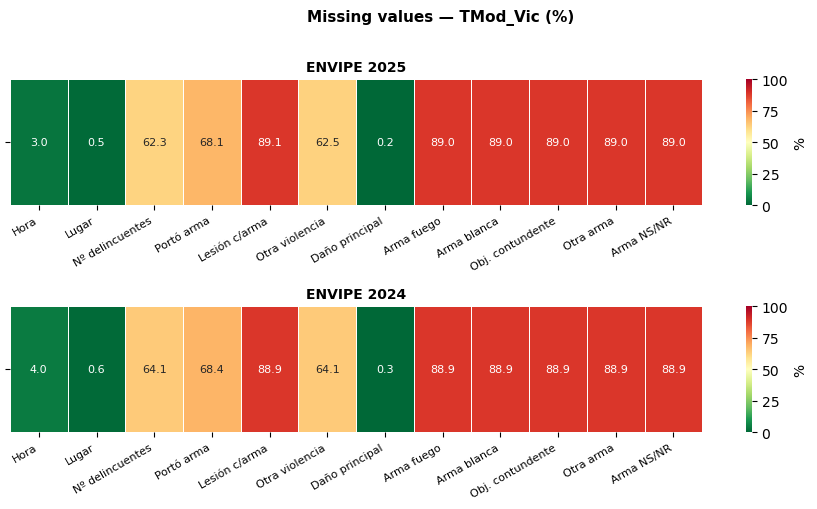

In [40]:
vars_check = list(no_respuesta.keys())
bp1_16_cols = [c for c in df_Mod_Vic.columns if c.startswith('BP1_16_')]
vars_check_full = vars_check + bp1_16_cols

etiquetas = {
    'BP1_4':    'Hora',
    'BP1_5':    'Lugar',
    'BP1_9':    'Nº delincuentes',
    'BP1_15':   'Portó arma',
    'BP1_17':   'Lesión c/arma',
    'BP1_18':   'Otra violencia',
    'BP1_33':   'Daño principal',
    'BP1_16_1': 'Arma fuego',
    'BP1_16_2': 'Arma blanca',
    'BP1_16_3': 'Obj. contundente',
    'BP1_16_4': 'Otra arma',
    'BP1_16_9': 'Arma NS/NR',
}

etiquetas_display = [etiquetas.get(v, v) for v in vars_check_full]

fig, axes = plt.subplots(2, 1, figsize=(9, 5))

for ax, (df, año) in zip(axes, [(df_Mod_Vic, '2025'), (df_Mod_Vic_2024, '2024')]):

    missing = df[vars_check_full].isna().mean() * 100
    missing_df = pd.DataFrame([missing.values], columns=etiquetas_display)

    sns.heatmap(
        missing_df,
        ax=ax,
        annot=True,
        fmt='.1f',
        cmap='RdYlGn_r',
        vmin=0, vmax=100,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': '%'},
        annot_kws={'size': 8}
    )

    ax.set_title(f'ENVIPE {año}', fontsize=10, fontweight='bold', pad=6)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels([])
    ax.set_ylabel('')

plt.suptitle('Missing values — TMod_Vic (%)', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [41]:
# Ahora, traigamos del archivo de "Poster" algunas variables que nos pueda servir.
# Acá pongo un resumen de cuales podrían ser más algunas extras de mirar el diccionario 

In [42]:
# ------------------------------------------------------------
# TPer_Vic1: percepción de inseguridad y miedo conductual
# ------------------------------------------------------------

# AP4_3_1  = percepción de inseguridad en colonia o localidad
# AP4_3_2  = percepción de inseguridad en municipio o demarcación territorial

# AP4_4_01 = percepción de seguridad/inseguridad en casa
# AP4_4_03 = percepción de seguridad/inseguridad en calle
# AP4_4_05 = percepción de seguridad/inseguridad en mercado
# AP4_4_06 = percepción de seguridad/inseguridad en centro comercial
# AP4_4_07 = percepción de seguridad/inseguridad en banco
# AP4_4_08 = percepción de seguridad/inseguridad en cajero automático
# AP4_4_09 = percepción de seguridad/inseguridad en transporte público
# AP4_4_12 = percepción de seguridad/inseguridad en parque o centro recreativo
# AP4_4_A  = percepción de seguridad/inseguridad al caminar solo/a de noche

# AP4_10_01 = dejó de salir de noche por temor a ser víctima de delito
# AP4_10_02 = dejó de permitir que menores salieran por temor al delito
# AP4_10_03 = dejó de visitar parientes o amigos por temor al delito
# AP4_10_04 = dejó de usar joyas por temor al delito
# AP4_10_05 = dejó de llevar dinero en efectivo por temor al delito
# AP4_10_06 = dejó de usar tarjeta de crédito o débito por temor al delito
# AP4_10_08 = dejó de usar transporte público por temor al delito
# AP4_10_09 = dejó de ir al cine o teatro por temor al delito
# AP4_10_10 = dejó de salir a caminar por temor al delito
# AP4_10_11 = dejó de ir a comer o cenar fuera por temor al delito
# AP4_10_12 = dejó de ir al estadio por temor al delito
# AP4_10_14 = dejó de viajar por carretera a otro estado o municipio por temor al delito
# AP4_10_15 = dejó de llevar teléfono celular por temor al delito


# ------------------------------------------------------------
# TPer_Vic2: victimización personal
# ------------------------------------------------------------

# AP7_3_* = indica si la persona sufrió directamente determinados tipos de delito
# AP7_4_* = cantidad de veces que la persona sufrió cada tipo de delito


In [43]:
bases = {
    "2024": {
        "per1": df_TPer_Vic1_2024,
        "per2": df_TPer_Vic2_2024,
        "mod":  df_Mod_Vic_2024
    },
    "2025": {
        "per1": df_TPer_Vic1,
        "per2": df_TPer_Vic2,
        "mod":  df_Mod_Vic
    }
}

In [44]:
# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def limpiar_a_numerico(s):
    """
    Convierte valores tipo 'b', blancos, True/False y strings numéricos
    a códigos numéricos utilizables.
    """
    s = s.replace({
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "TRUE": 1,
        "FALSE": 0,
        "b": np.nan,
        "B": np.nan,
        "": np.nan,
        " ": np.nan,
        "nan": np.nan,
        "NaN": np.nan,
        "None": np.nan,
        None: np.nan
    })
    
    return pd.to_numeric(s, errors="coerce")


def recodificar_directo(df, cols, mapa):
    """
    Recodifica directamente en el dataframe original.
    No crea columnas _bin.
    """
    cols_existentes = [c for c in cols if c in df.columns]
    
    for c in cols_existentes:
        s = limpiar_a_numerico(df[c])
        df[c] = s.map(mapa).astype(float)
    
    return df


def limpiar_conteos(df, cols):
    """
    Para variables de cantidad, por ejemplo AP7_4_*.
    Convierte 'b' y otros valores no numéricos a NaN.
    """
    cols_existentes = [c for c in cols if c in df.columns]
    
    for c in cols_existentes:
        df[c] = limpiar_a_numerico(df[c]).astype(float)
    
    return df


def missing_percent(df, cols):
    cols = [c for c in cols if c in df.columns]
    return (
        df[cols]
        .isna()
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )


def plot_missing_bar(missing_series, title, figsize=(12, 6)):
    if missing_series.empty:
        print(f"No hay variables para graficar en: {title}")
        return
    
    data = missing_series.sort_values(ascending=True)
    
    cmap = plt.cm.RdYlGn_r
    norm = plt.Normalize(vmin=0, vmax=100)
    colors = cmap(norm(data.values))
    
    plt.figure(figsize=figsize)
    plt.barh(data.index, data.values, color=colors)
    plt.xlabel("% de valores faltantes")
    plt.title(title)
    plt.xlim(0, 100)
    
    for i, v in enumerate(data.values):
        plt.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
    
    plt.tight_layout()
    plt.show()


def plot_missing_heatmap_percent(missing_series, title, figsize=(14, 2.8)):
    if missing_series.empty:
        print(f"No hay variables para graficar en: {title}")
        return
    
    df_plot = missing_series.to_frame().T
    df_plot.index = ["% missing"]
    
    plt.figure(figsize=figsize)
    sns.heatmap(
        df_plot,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn_r",
        vmin=0,
        vmax=100,
        cbar_kws={"label": "% missing"}
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [45]:
labels = {
    # AP4_3 - percepción geográfica
    "AP4_3_1": "Inseguridad colonia/localidad",
    "AP4_3_2": "Inseguridad municipio",

    # AP4_4 - percepción en espacios
    "AP4_4_01": "Casa",
    "AP4_4_03": "Calle",
    "AP4_4_05": "Mercado",
    "AP4_4_06": "Centro comercial",
    "AP4_4_07": "Banco",
    "AP4_4_08": "Cajero automático",
    "AP4_4_09": "Transporte público",
    "AP4_4_12": "Parque / espacio público",
    "AP4_4_A":  "Caminar de noche",

    # AP4_10 - cambios de hábitos por miedo (orden corregido según diccionario ENVIPE)
    "AP4_10_01": "Dejar salir de noche",
    "AP4_10_02": "Dejar salir a menores solos",
    "AP4_10_03": "Dejar visitar familiares/amigos",
    "AP4_10_04": "Dejar tomar taxi",
    "AP4_10_05": "Dejar usar transporte público",
    "AP4_10_06": "Dejar llevar efectivo",
    "AP4_10_08": "Dejar ir al cine/teatro",
    "AP4_10_09": "Dejar salir a caminar",
    "AP4_10_10": "Dejar usar joyas",
    "AP4_10_11": "Dejar salir a comer/cenar",
    "AP4_10_12": "Dejar llevar tarjeta bancaria",
    "AP4_10_13": "Dejar ir al estadio",
    "AP4_10_14": "Dejar ir al centro comercial",
    "AP4_10_15": "Dejar viajar por carretera",
}

In [46]:
def rename_missing_index(missing_series, labels_dict):
    return missing_series.rename(index=lambda x: labels_dict.get(x, x))

In [47]:
resultados = {}

# Mapas de recodificación directa
# Resultado final:
# 1 = presencia del fenómeno de interés
# 0 = ausencia del fenómeno de interés
# NaN = no aplica / no sabe / no responde / blanco

mapa_seguridad_geografica = {
    1: 0,        # Seguro
    2: 1,        # Inseguro
    9: np.nan    # No sabe / no responde
}

mapa_seguridad_espacios = {
    1: 0,        # Seguro
    2: 1,        # Inseguro
    3: np.nan,   # No aplica
    9: np.nan    # No sabe / no responde
}

mapa_caminar_noche = {
    1: 0,        # Muy seguro
    2: 0,        # Seguro
    3: 1,        # Inseguro
    4: 1,        # Muy inseguro
    5: np.nan,   # No aplica
    9: np.nan    # No sabe / no responde
}

mapa_si_no_noaplica = {
    1: 1,        # Sí
    2: 0,        # No
    3: np.nan,   # No aplica
    9: np.nan    # No sabe / no responde
}

mapa_si_no = {
    1: 1,        # Sí
    2: 0,        # No
    9: np.nan    # No sabe / no responde
}


for year, dfs in bases.items():
    
    per1 = dfs["per1"]
    per2 = dfs["per2"]
    
    # Por si ya habías corrido el bloque anterior y quedaron columnas _bin
    per1.drop(columns=[c for c in per1.columns if c.endswith("_bin")], inplace=True, errors="ignore")
    per2.drop(columns=[c for c in per2.columns if c.endswith("_bin")], inplace=True, errors="ignore")
    
    # ------------------------------------------------------------
    # Variables seleccionadas de percepción
    # ------------------------------------------------------------
    
    cols_ap43 = [
        "AP4_3_1",
        "AP4_3_2"
    ]
    
    cols_ap44 = [
        "AP4_4_01",
        "AP4_4_03",
        "AP4_4_05",
        "AP4_4_06",
        "AP4_4_07",
        "AP4_4_08",
        "AP4_4_09",
        "AP4_4_12"
    ]
    
    cols_ap44a = [
        "AP4_4_A"
    ]
    
    cols_ap410 = [
        "AP4_10_01",
        "AP4_10_02",
        "AP4_10_03",
        "AP4_10_04",
        "AP4_10_05",
        "AP4_10_06",
        "AP4_10_08",
        "AP4_10_09",
        "AP4_10_10",
        "AP4_10_11",
        "AP4_10_12",
        "AP4_10_13",
        "AP4_10_14",
        "AP4_10_15"
    ]
    
    # ------------------------------------------------------------
    # Variables AP7: victimización personal
    # ------------------------------------------------------------
    
    cols_ap73 = [c for c in per2.columns if c.startswith("AP7_3")]
    cols_ap74 = [c for c in per2.columns if c.startswith("AP7_4")]
    
    # ------------------------------------------------------------
    # Limpieza directa sobre matrices originales
    # ------------------------------------------------------------
    
    per1 = recodificar_directo(per1, cols_ap43, mapa_seguridad_geografica)
    per1 = recodificar_directo(per1, cols_ap44, mapa_seguridad_espacios)
    per1 = recodificar_directo(per1, cols_ap44a, mapa_caminar_noche)
    per1 = recodificar_directo(per1, cols_ap410, mapa_si_no_noaplica)
    
    per2 = recodificar_directo(per2, cols_ap73, mapa_si_no)
    per2 = limpiar_conteos(per2, cols_ap74)
    
    resultados[year] = {
        "per1": per1,
        "per2": per2,
        "cols_ap43": cols_ap43,
        "cols_ap44": cols_ap44,
        "cols_ap44a": cols_ap44a,
        "cols_ap410": cols_ap410,
        "cols_ap73": cols_ap73,
        "cols_ap74": cols_ap74
    }

In [48]:
tablas_missing = {}

for year, res in resultados.items():
    
    per1 = res["per1"]
    per2 = res["per2"]
    
    vars_ap_percepcion = (
        res["cols_ap43"] +
        res["cols_ap44"] +
        res["cols_ap44a"]
    )
    
    vars_ap_miedo = res["cols_ap410"]
    
    vars_ap7 = (
        res["cols_ap73"] +
        res["cols_ap74"]
    )
    
    tablas_missing[(year, "AP percepción")] = missing_percent(per1, vars_ap_percepcion)
    tablas_missing[(year, "AP miedo conductual")] = missing_percent(per1, vars_ap_miedo)
    tablas_missing[(year, "AP7 victimización")] = missing_percent(per2, vars_ap7)

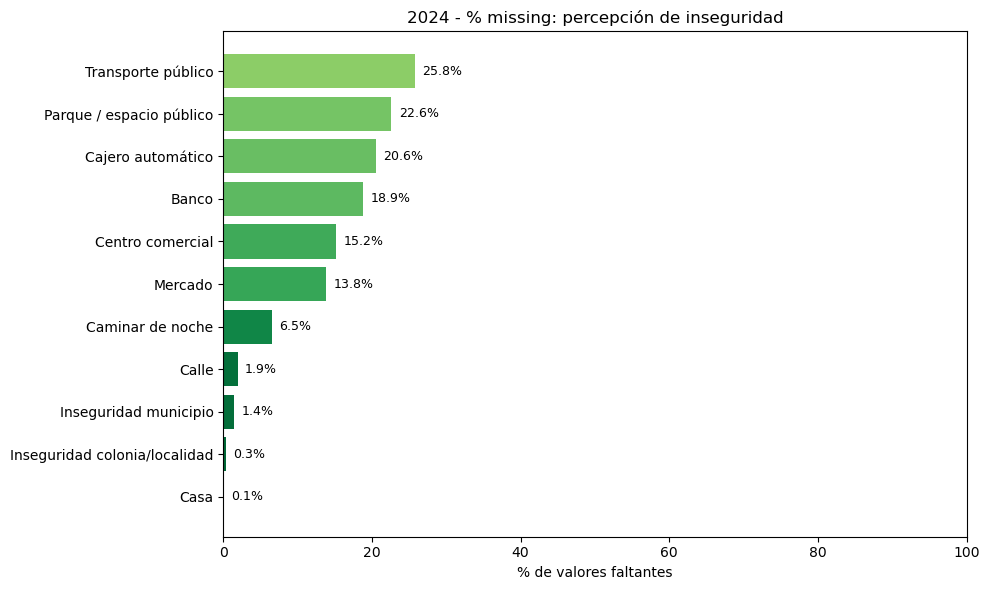

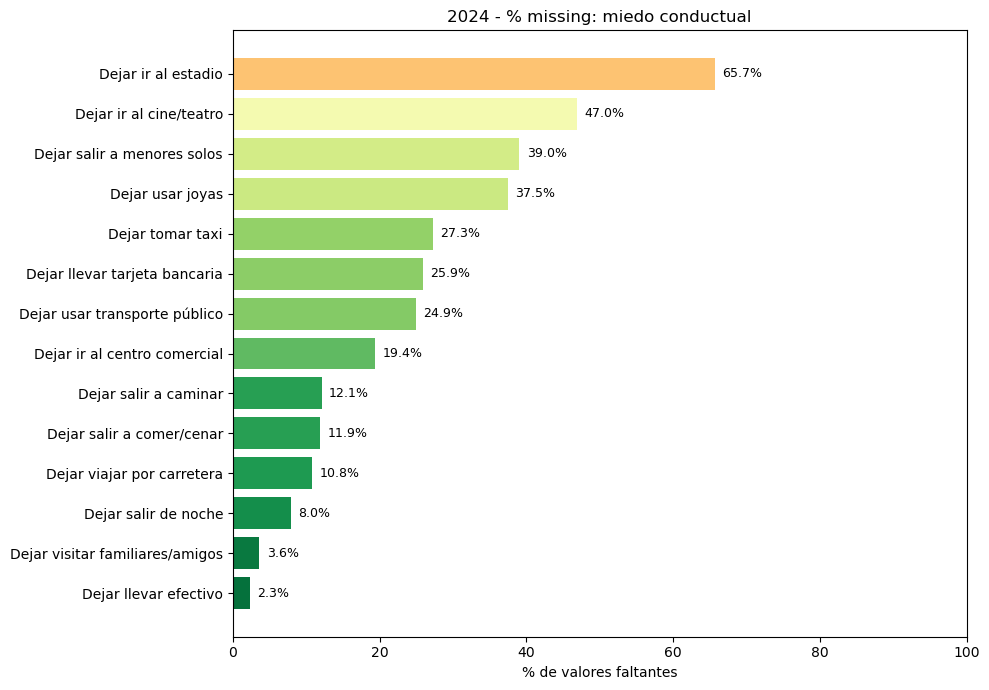

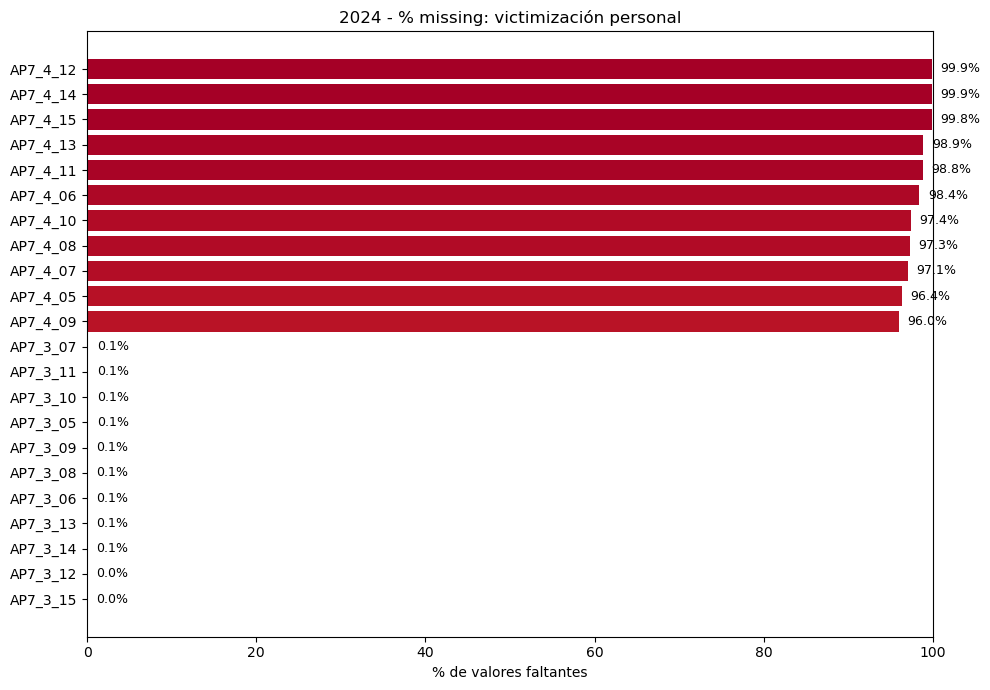

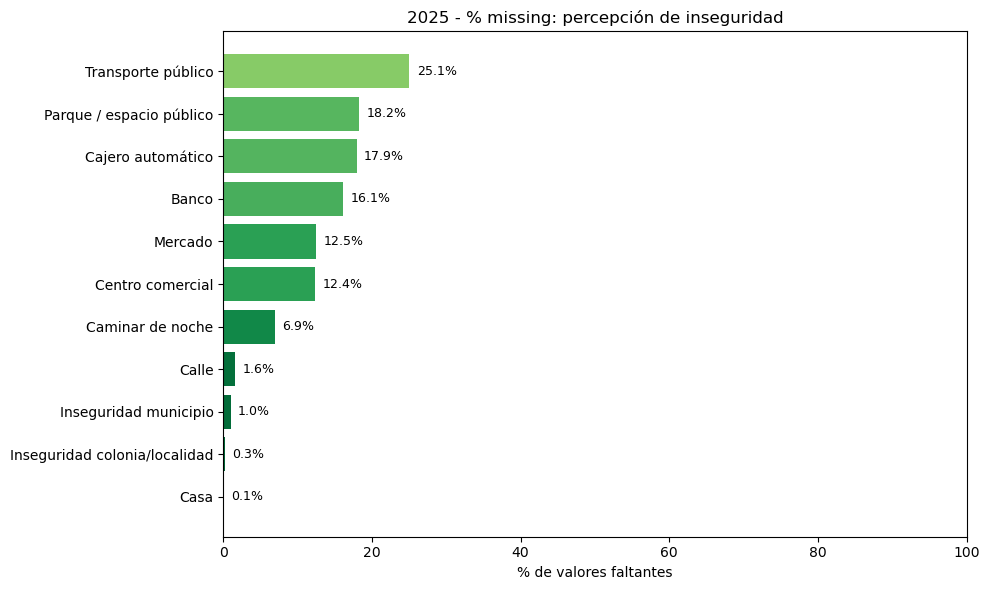

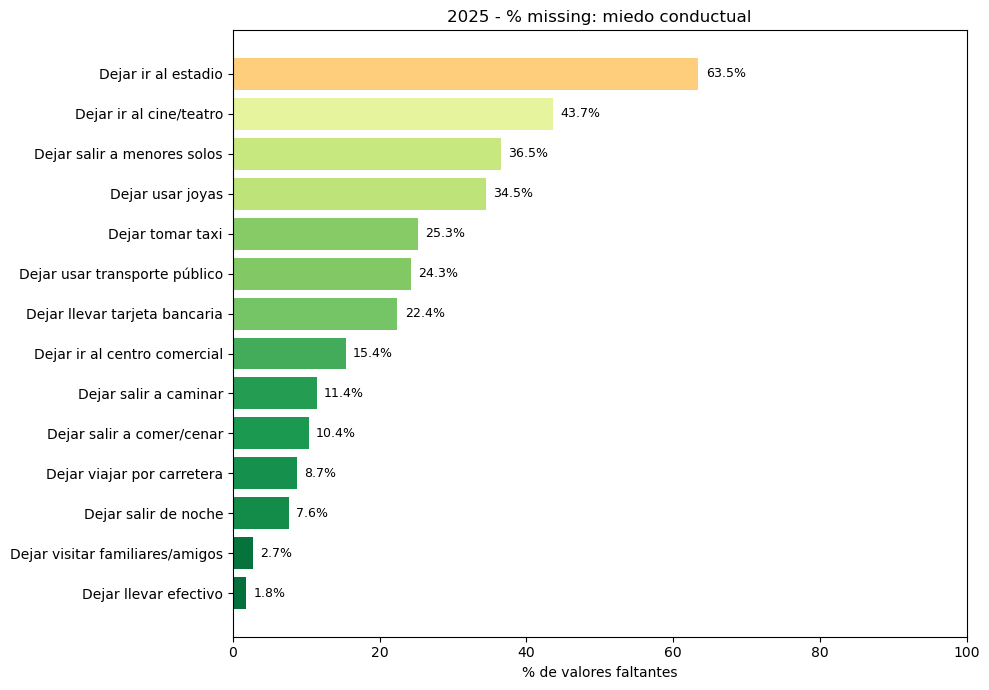

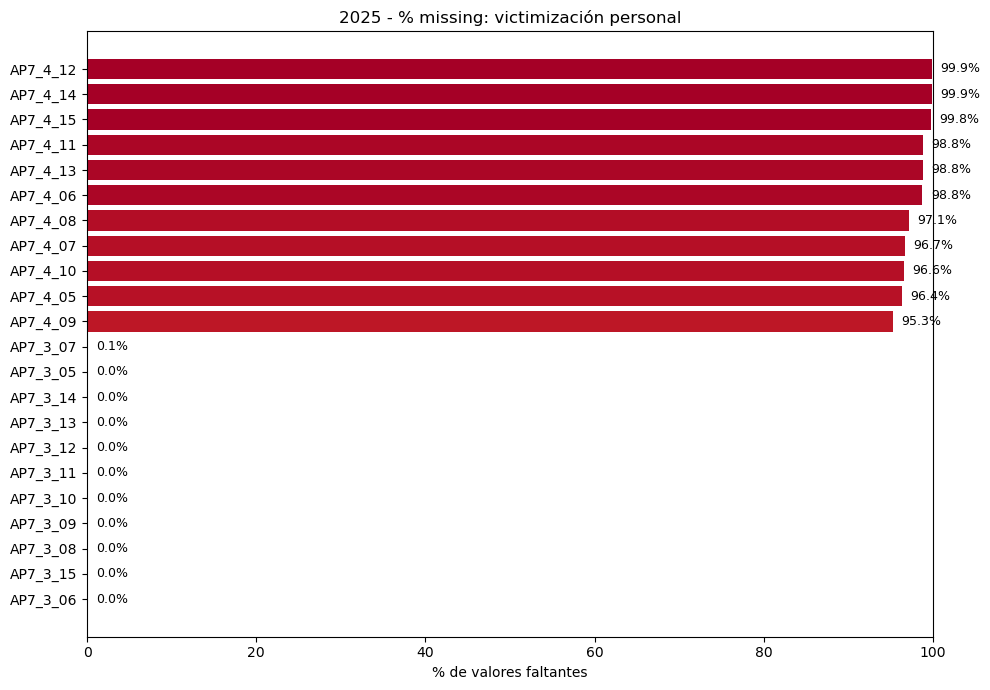

In [49]:
for year in resultados.keys():
    
    m = rename_missing_index(tablas_missing[(year, "AP percepción")], labels)
    plot_missing_bar(
        m,
        title=f"{year} - % missing: percepción de inseguridad",
        figsize=(10, 6)
    )
    
    m = rename_missing_index(tablas_missing[(year, "AP miedo conductual")], labels)
    plot_missing_bar(
        m,
        title=f"{year} - % missing: miedo conductual",
        figsize=(10, 7)
    )
    
    m = rename_missing_index(tablas_missing[(year, "AP7 victimización")], labels)
    plot_missing_bar(
        m,
        title=f"{year} - % missing: victimización personal",
        figsize=(10, 7)
    )

In [50]:
# Como estadística descriptiva, podríamos ver de manera priliminar mediante una matriz de correlaciones 
# que tanto se estan explicando las variables de AP y BD:

In [51]:
# -------------------------------
# 1. Variables a usar
# -------------------------------

ids = ["UPM", "VIV_SEL", "HOGAR", "R_SEL"]

bp_binarias = [
    "BP1_15",    # Portó arma
    "BP1_17",    # Lesión c/arma
    "BP1_18",    # Otra violencia
    "BP1_16_1",  # Arma fuego
    "BP1_16_2",  # Arma blanca
    "BP1_16_3",  # Obj. contundente
    "BP1_16_4",  # Otra arma
    "BP1_16_9",  # Arma NS/NR
]

bp_categoricas = [
    "BP1_4",     # Hora
    "BP1_5",     # Lugar
    "BP1_9",     # N° delincuentes
    "BP1_33",    # Daño principal
]

etiquetas_bp = {
    "BP1_4": "Hora",
    "BP1_5": "Lugar",
    "BP1_9": "N° delincuentes",
    "BP1_15": "Portó arma",
    "BP1_17": "Lesión c/arma",
    "BP1_18": "Otra violencia",
    "BP1_33": "Daño principal",
    "BP1_16_1": "Arma fuego",
    "BP1_16_2": "Arma blanca",
    "BP1_16_3": "Obj. contundente",
    "BP1_16_4": "Otra arma",
    "BP1_16_9": "Arma NS/NR",
}

In [52]:
# -------------------------------
# 2. Funciones auxiliares
# -------------------------------

def normalizar_columnas(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip().str.upper()
    return df

def normalizar_valores(s):
    return (
        s.astype("string")
         .str.strip()
         .str.upper()
         .str.replace(r"\.0$", "", regex=True)
    )

def a_binaria_01(s):
    """
    Sirve tanto si la variable está en formato original:
    1 = Sí, 2 = No
    como si ya fue limpiada:
    1 = Sí, 0 = No
    """
    x = normalizar_valores(s)

    return x.map({
        "1": 1,
        "0": 0,
        "2": 0,
        "TRUE": 1,
        "FALSE": 0
    }).astype("float")

def etiqueta_columna_bp(col):
    if col in etiquetas_bp:
        return etiquetas_bp[col]

    for pref in sorted(etiquetas_bp.keys(), key=len, reverse=True):
        if col.startswith(pref + "_"):
            valor = col.replace(pref + "_", "")
            return f"{etiquetas_bp[pref]}={valor}"

    return col

In [53]:
# -------------------------------
# 3. Preparar matriz AP-BP
# -------------------------------

def preparar_matriz_ap_bp(df_tper_vic2, df_tmod_vic, solo_victimas=True):
    """
    df_tper_vic2: base TPer_Vic2, nivel persona
    df_tmod_vic: base TMod_Vic, nivel delito

    solo_victimas=True:
        arma la matriz solo con personas que aparecen en TMod_Vic.
        Es lo más razonable para no inflar correlaciones con miles de no víctimas.

    solo_victimas=False:
        conserva todas las personas de TPer_Vic2 y pone 0 en BP cuando no aparece delito.
    """

    tper = normalizar_columnas(df_tper_vic2)
    tmod = normalizar_columnas(df_tmod_vic)

    # -------------------------------
    # AP: victimización personal
    # -------------------------------

    ap_cols = sorted([
        c for c in tper.columns
        if re.match(r"^AP7_3_\d{2}$", c)
    ])

    ap_persona = tper[ids + ap_cols].copy()

    for col in ap_cols:
        ap_persona[col] = a_binaria_01(ap_persona[col])

    # -------------------------------
    # BP binarias: agregarlas a nivel persona
    # Si una persona tuvo más de un delito, queda 1 si ocurrió al menos una vez.
    # -------------------------------

    bp_binarias_presentes = [c for c in bp_binarias if c in tmod.columns]

    bp_bin = tmod[ids + bp_binarias_presentes].copy()

    for col in bp_binarias_presentes:
        bp_bin[col] = a_binaria_01(bp_bin[col])

    bp_bin_persona = (
        bp_bin
        .groupby(ids, as_index=False)
        .max()
    )

    # -------------------------------
    # BP categóricas: dummies y luego agregación a nivel persona
    # Ejemplo: BP1_4=1, BP1_4=2, etc.
    # -------------------------------

    dummies_list = []

    for col in bp_categoricas:
        if col not in tmod.columns:
            continue

        aux = tmod[ids + [col]].copy()
        x = normalizar_valores(aux[col])

        # valores claramente no informativos
        x = x.mask(x.isin(["", "B", "BLANCO", "NAN", "<NA>", "9", "99", "999"]))

        dum = pd.get_dummies(x, prefix=col, dummy_na=False).astype(int)
        aux = pd.concat([aux[ids], dum], axis=1)

        dummies_list.append(aux)

    if len(dummies_list) > 0:
        bp_cat = pd.concat(dummies_list, axis=0, ignore_index=True)
        bp_cat_persona = (
            bp_cat
            .groupby(ids, as_index=False)
            .max()
        )
    else:
        bp_cat_persona = pd.DataFrame(columns=ids)

    # -------------------------------
    # Unir BP binarias + BP categóricas a nivel persona
    # -------------------------------

    bp_persona = bp_bin_persona.merge(
        bp_cat_persona,
        on=ids,
        how="outer"
    )

    bp_cols = [c for c in bp_persona.columns if c not in ids]
    bp_persona[bp_cols] = bp_persona[bp_cols].fillna(0)

    # -------------------------------
    # Unir AP y BP
    # -------------------------------

    if solo_victimas:
        base_ap_bp = ap_persona.merge(bp_persona, on=ids, how="inner")
    else:
        base_ap_bp = ap_persona.merge(bp_persona, on=ids, how="left")
        base_ap_bp[bp_cols] = base_ap_bp[bp_cols].fillna(0)

    # -------------------------------
    # Eliminar columnas sin variación
    # -------------------------------

    ap_validas = [
        c for c in ap_cols
        if c in base_ap_bp.columns and base_ap_bp[c].nunique(dropna=True) > 1
    ]

    bp_validas = [
        c for c in bp_cols
        if c in base_ap_bp.columns and base_ap_bp[c].nunique(dropna=True) > 1
    ]

    # -------------------------------
    # Correlación AP vs BP
    # -------------------------------

    corr_total = base_ap_bp[ap_validas + bp_validas].corr(
        method="pearson",
        min_periods=30
    )

    corr_ap_bp = corr_total.loc[ap_validas, bp_validas]

    corr_ap_bp = corr_ap_bp.dropna(how="all").dropna(axis=1, how="all")

    corr_ap_bp_etiquetada = corr_ap_bp.rename(
        columns={c: etiqueta_columna_bp(c) for c in corr_ap_bp.columns}
    )

    return base_ap_bp, corr_ap_bp, corr_ap_bp_etiquetada

In [54]:
base_ap_bp_2025, corr_ap_bp_2025, corr_ap_bp_2025_etiquetada = preparar_matriz_ap_bp(
    df_TPer_Vic2,
    df_Mod_Vic,
    solo_victimas=True
)

corr_ap_bp_2025_etiquetada

,Portó arma,Lesión c/arma,Otra violencia,Arma fuego,Arma blanca,Obj. contundente,Otra arma,Arma NS/NR,Hora=1,Hora=2,...,N° delincuentes=2,N° delincuentes=3,N° delincuentes=4,N° delincuentes=5,N° delincuentes=6,Daño principal=1,Daño principal=2,Daño principal=3,Daño principal=4,Daño principal=5
AP7_3_05,0.579357,0.125026,0.151201,0.445338,0.428752,0.049230,0.029615,0.031062,0.071310,0.061844,...,0.415613,0.217635,0.126301,0.075113,0.037255,0.169871,0.060846,0.012596,-0.001963,-0.075235
AP7_3_06,-0.008492,0.003512,-0.013121,-0.005965,-0.004031,0.004326,-0.000026,-0.007225,-0.002141,-0.019745,...,-0.002939,-0.015558,-0.008762,-0.009726,0.000878,0.097755,-0.005104,-0.023277,0.007264,-0.043257
AP7_3_07,-0.056797,-0.009899,-0.012092,-0.045103,-0.026159,-0.008151,-0.007603,0.016528,0.103766,0.128669,...,-0.038188,-0.016016,-0.011678,-0.011973,-0.022277,0.151868,-0.020180,-0.025506,0.000603,0.048207
AP7_3_08,-0.032068,0.001613,0.011412,-0.033904,-0.001941,-0.005068,0.007680,0.006281,0.111085,0.185551,...,-0.022482,-0.002151,-0.009665,-0.006429,-0.003965,0.221716,0.012556,-0.029588,0.000352,-0.027585
AP7_3_09,-0.057715,-0.025991,-0.052135,-0.021053,-0.054575,-0.010485,-0.010831,0.010018,0.169788,0.171198,...,0.046562,0.015156,0.017420,0.001743,0.009049,-0.291597,-0.040866,0.195313,-0.012154,0.348650
AP7_3_10,0.103265,0.054361,0.163813,0.055478,0.082990,0.086398,0.018276,0.036925,0.091438,0.136311,...,0.140322,0.111559,0.069542,0.069928,0.094356,-0.187378,0.134201,0.353078,0.071661,0.144092
AP7_3_11,0.131139,0.196718,0.674715,0.066302,0.100290,0.141014,0.000142,0.039201,0.039196,0.068182,...,0.124583,0.086194,0.079986,0.069939,0.139815,-0.087036,0.548547,0.126278,0.020816,0.003922
AP7_3_12,0.112606,0.083659,0.078009,0.134316,0.037197,0.025012,-0.001706,-0.001789,0.013002,0.006137,...,0.017399,0.039352,0.092288,0.079086,0.133965,0.003951,0.025885,0.037599,0.005330,-0.004778
AP7_3_13,0.003449,0.010456,0.108860,-0.006211,0.009298,0.004488,0.006899,0.025611,0.074904,0.098932,...,0.032957,0.019606,0.002510,0.016568,-0.000461,-0.116452,0.066900,0.325354,0.033211,0.000106
AP7_3_14,0.041107,0.039007,0.148431,0.032054,0.029101,0.030657,-0.002091,0.018382,0.018070,0.018536,...,0.015786,0.023925,0.015464,-0.000905,0.014612,-0.027608,0.075442,0.098799,-0.005607,-0.014132


In [55]:
base_ap_bp_2024, corr_ap_bp_2024, corr_ap_bp_2024_etiquetada = preparar_matriz_ap_bp(
    df_TPer_Vic2_2024,
    df_Mod_Vic_2024,
    solo_victimas=True
)

corr_ap_bp_2024_etiquetada

,Portó arma,Lesión c/arma,Otra violencia,Arma fuego,Arma blanca,Obj. contundente,Otra arma,Arma NS/NR,Hora=1,Hora=2,...,N° delincuentes=2,N° delincuentes=3,N° delincuentes=4,N° delincuentes=5,N° delincuentes=6,Daño principal=1,Daño principal=2,Daño principal=3,Daño principal=4,Daño principal=5
AP7_3_05,0.607293,0.130817,0.158568,0.473391,0.437568,0.036497,0.044510,0.054709,0.081659,0.066837,...,0.442553,0.224014,0.132024,0.062819,0.060591,0.149054,0.066422,0.009359,0.003323,-0.069710
AP7_3_06,-0.028876,-0.000102,-0.028435,-0.023826,-0.013789,-0.002462,0.013791,0.001539,-0.019138,-0.027127,...,-0.029533,-0.020842,0.005543,0.000084,-0.005406,0.104487,-0.021988,-0.050068,0.008180,-0.032232
AP7_3_07,-0.059548,-0.019918,-0.019534,-0.049011,-0.027740,-0.002572,-0.006326,-0.002597,0.105667,0.124834,...,-0.045478,-0.021469,-0.014742,-0.017489,-0.027180,0.142885,-0.023896,-0.031613,-0.004309,0.036583
AP7_3_08,-0.052178,-0.015152,0.004530,-0.038306,-0.026305,-0.004448,0.001493,-0.001571,0.124729,0.169195,...,-0.038972,-0.016064,-0.015337,-0.006721,-0.006828,0.207161,0.002472,-0.045427,0.005243,-0.040686
AP7_3_09,-0.065057,-0.011572,-0.034527,-0.041140,-0.045549,-0.007859,-0.007771,-0.001881,0.158884,0.191652,...,0.041520,0.017213,0.006312,0.001931,0.012247,-0.285074,-0.029483,0.219182,0.009166,0.322008
AP7_3_10,0.103956,0.057655,0.185925,0.054314,0.084454,0.102903,0.050585,0.006800,0.073121,0.126141,...,0.114800,0.103298,0.080633,0.067579,0.091353,-0.172070,0.167022,0.318810,0.083419,0.097688
AP7_3_11,0.126058,0.167900,0.668718,0.067237,0.086412,0.138779,0.091779,0.010429,0.046579,0.076707,...,0.109994,0.112881,0.090988,0.075599,0.123166,-0.087481,0.547334,0.116262,0.019664,0.009161
AP7_3_12,0.096484,0.035992,0.067764,0.112527,0.018096,-0.004940,0.037420,-0.002402,0.027668,-0.000608,...,0.017273,0.039106,0.083085,0.032494,0.116839,-0.018888,0.025362,0.042095,0.003733,-0.014072
AP7_3_13,-0.005110,0.013249,0.112713,-0.015115,0.015462,0.007906,0.015731,0.000658,0.061850,0.082786,...,0.040564,0.043261,0.018142,0.020888,0.002153,-0.127378,0.065396,0.325010,0.037350,0.010733
AP7_3_14,0.027630,0.044550,0.120719,0.014546,0.028945,0.003477,-0.002667,0.015548,0.017139,0.012607,...,0.025276,0.022501,0.018979,-0.005612,0.017414,-0.027507,0.052405,0.091012,-0.005833,-0.000830


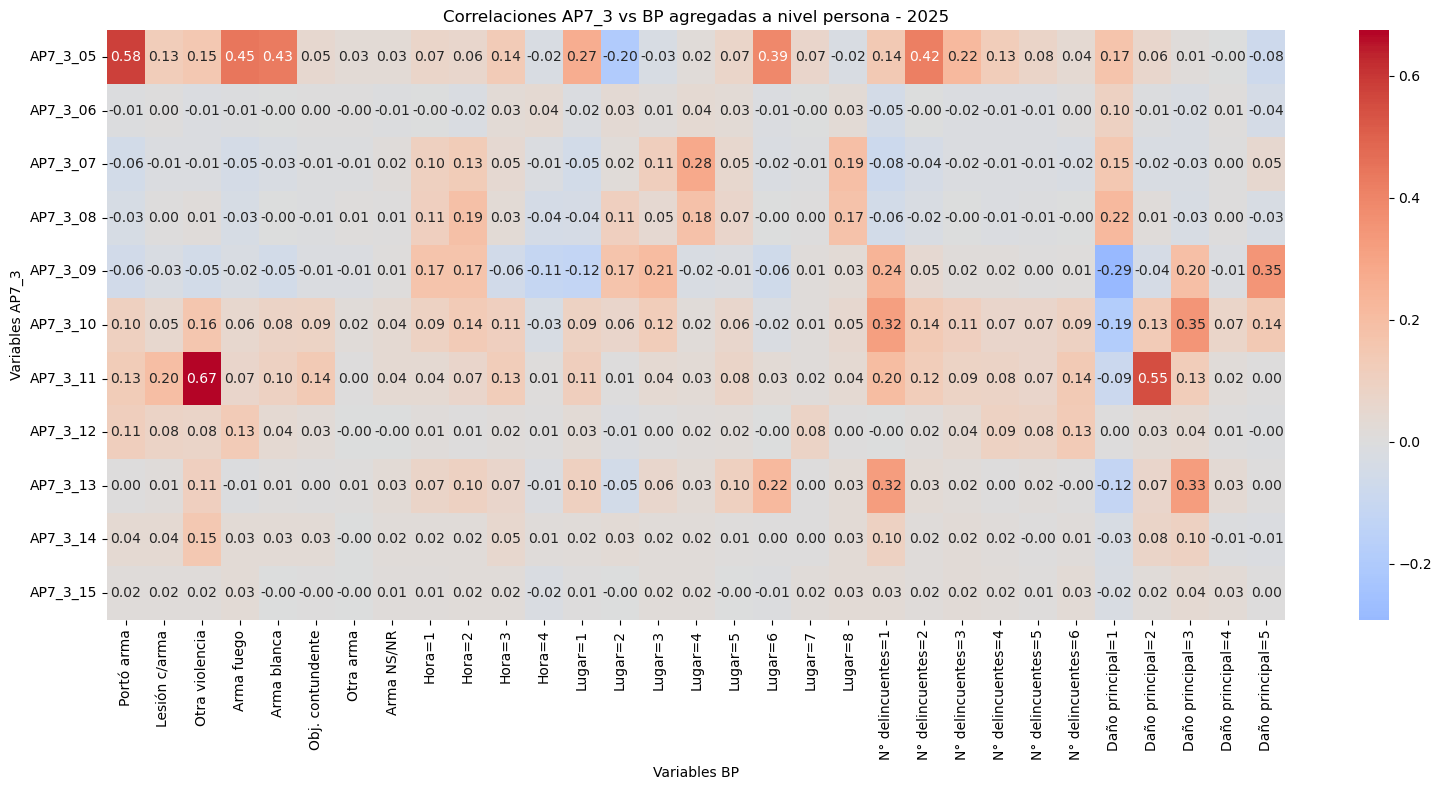

In [56]:
plt.figure(figsize=(16, 8))
sns.heatmap(
    corr_ap_bp_2025_etiquetada,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)
plt.title("Correlaciones AP7_3 vs BP agregadas a nivel persona - 2025")
plt.xlabel("Variables BP")
plt.ylabel("Variables AP7_3")
plt.tight_layout()
plt.show()

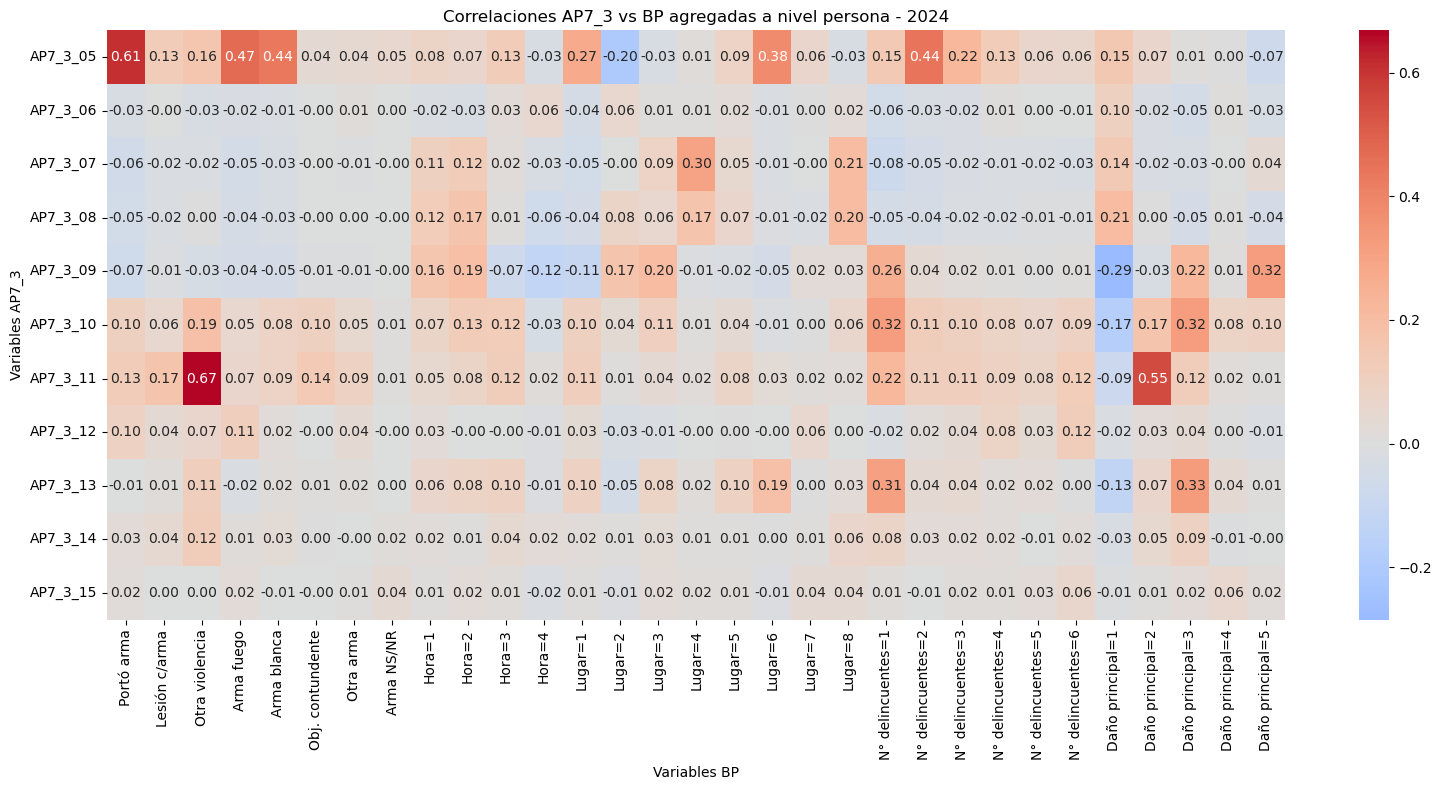

In [57]:
plt.figure(figsize=(16, 8))
sns.heatmap(
    corr_ap_bp_2024_etiquetada,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)
plt.title("Correlaciones AP7_3 vs BP agregadas a nivel persona - 2024")
plt.xlabel("Variables BP")
plt.ylabel("Variables AP7_3")
plt.tight_layout()
plt.show()

In [58]:
# Después, se nos menciono que algunas de las otras variables referidas al secuestro, hostigamiento, fraude y extorsión podrían ser interesantes
# a la hora del análisis de lo conductual.

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# Secuestro
# ─────────────────────────────────────────────────────────────────────────────

# AP7_3_12   Lo/la secuestraron para exigir dinero o bienes
# AP7_4_12   Cuántas veces

# AP6_9      Antes del año de referencia, algún integrante del hogar, incluido usted, sufrió secuestro
# AP6_10_1   Durante el año de referencia, algún integrante del hogar, incluido usted, sufrió secuestro


# ─────────────────────────────────────────────────────────────────────────────
# Hostigamiento
# ─────────────────────────────────────────────────────────────────────────────

# AP7_3_13 refiere a hostigamiento o intimidación sexual, manoseo, exhibicionismo o intento de violación.

# ─────────────────────────────────────────────────────────────────────────────
# Fraude / Extorsión
# ─────────────────────────────────────────────────────────────────────────────

# AP7_3_07  fraude bancario / uso de tarjeta, chequera o cuenta sin permiso
# AP7_3_08  fraude al consumidor
# AP7_3_09  extorsión

# Sus respectivas cantidades, es decir, la cantidad de veces que sufrió el acto
# AP7_4_07
# AP7_4_08
# AP7_4_09

In [60]:
# ============================================================
# BLOQUE 59/60 CORREGIDO
# Limpieza directa sobre los dataframes originales TPer_Vic2
# ============================================================

vars_secuestro_hogar = [
    "AP6_9",      # Secuestro hogar antes del año de referencia
    "AP6_10_1"   # Secuestro hogar durante el año de referencia
]

vars_ap7_binarias = [
    "AP7_3_07",  # Fraude bancario
    "AP7_3_08",  # Fraude al consumidor
    "AP7_3_09",  # Extorsión
    "AP7_3_12",  # Secuestro personal
    "AP7_3_13"   # Hostigamiento / intimidación sexual
]

pares_ap7_cantidad = {
    "AP7_3_07": "AP7_4_07",
    "AP7_3_08": "AP7_4_08",
    "AP7_3_09": "AP7_4_09",
    "AP7_3_12": "AP7_4_12",
    "AP7_3_13": "AP7_4_13"
}

vars_limpieza_ap = (
    vars_secuestro_hogar +
    vars_ap7_binarias +
    list(pares_ap7_cantidad.values())
)


def limpiar_base_numerica(s):
    """
    Convierte códigos no numéricos o blancos en NaN
    y deja todo en formato numérico.
    """
    s = s.replace({
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "TRUE": 1,
        "FALSE": 0,
        "b": np.nan,
        "B": np.nan,
        "": np.nan,
        " ": np.nan,
        "nan": np.nan,
        "NaN": np.nan,
        "None": np.nan,
        None: np.nan
    })
    
    return pd.to_numeric(s, errors="coerce")


def recodificar_binarias_en_original(df, cols):
    """
    Recodifica directamente en el dataframe original:
    1 = Sí  -> 1
    2 = No  -> 0
    9 = NS/NR -> NaN

    También tolera variables ya recodificadas:
    0 = No
    1 = Sí
    """
    for c in cols:
        if c not in df.columns:
            print(f"Variable no encontrada: {c}")
            continue
        
        s = limpiar_base_numerica(df[c])
        
        valores_no_esperados = sorted(
            set(s.dropna().unique()) - {0, 1, 2, 9}
        )
        
        if len(valores_no_esperados) > 0:
            print(f"Atención: {c} tiene valores no esperados: {valores_no_esperados}")
        
        df[c] = s.map({
            0: 0,        # ya estaba limpia
            1: 1,        # Sí
            2: 0,        # No
            9: np.nan    # No sabe / no responde
        }).astype(float)


def limpiar_cantidades_condicionales_en_original(df, pares):
    """
    Limpia AP7_4_* según su AP7_3_* correspondiente.

    Criterio:
    - Si AP7_3_* == 1, conserva cantidad válida 1 a 99.
    - Si AP7_3_* == 0, asigna 0 porque no sufrió ese hecho.
    - Si AP7_3_* == NaN, deja la cantidad como NaN.
    """

    for var_binaria, var_cantidad in pares.items():

        if var_binaria not in df.columns:
            print(f"Variable binaria no encontrada: {var_binaria}")
            continue

        if var_cantidad not in df.columns:
            print(f"Variable de cantidad no encontrada: {var_cantidad}")
            continue

        binaria = limpiar_base_numerica(df[var_binaria]).map({
            0: 0,        # ya estaba limpia
            1: 1,        # Sí
            2: 0,        # No
            9: np.nan    # No sabe / no responde
        })

        cantidad = limpiar_base_numerica(df[var_cantidad])

        # En el diccionario AP7_4 admite 1 a 99; b/blanco pasa a NaN.
        cantidad = cantidad.where(cantidad.between(1, 99), np.nan)

        # 0 no viene del diccionario: lo construimos solo cuando AP7_3 == No.
        cantidad.loc[binaria == 0] = 0

        # Si la binaria es missing, la cantidad también debe quedar missing.
        cantidad.loc[binaria.isna()] = np.nan

        df[var_cantidad] = cantidad.astype(float)
# ------------------------------------------------------------
# Aplicación directa sobre las bases originales
# ------------------------------------------------------------

bases_per2_originales = {
    "2024": df_TPer_Vic2_2024,
    "2025": df_TPer_Vic2
}

for year, per2 in bases_per2_originales.items():
    
    recodificar_binarias_en_original(
        per2,
        vars_secuestro_hogar + vars_ap7_binarias
    )
    
    limpiar_cantidades_condicionales_en_original(
        per2,
        pares_ap7_cantidad
    )

# ------------------------------------------------------------
# Asegurar que bases y resultados apunten a esas mismas bases
# ------------------------------------------------------------

bases["2024"]["per2"] = df_TPer_Vic2_2024
bases["2025"]["per2"] = df_TPer_Vic2

if "resultados" in globals():
    if "2024" in resultados:
        resultados["2024"]["per2"] = df_TPer_Vic2_2024
    if "2025" in resultados:
        resultados["2025"]["per2"] = df_TPer_Vic2

In [61]:
# ============================================================
# COMPROBACIÓN DE LIMPIEZA BLOQUE 59/60
# ============================================================

vars_binarias_59_60 = vars_secuestro_hogar + vars_ap7_binarias

def comprobar_limpieza_59_60(bases_per2_originales):
    filas = []

    for year, df in bases_per2_originales.items():

        # Comprobar binarias
        for c in vars_binarias_59_60:
            if c not in df.columns:
                filas.append({
                    "año": year,
                    "variable": c,
                    "tipo": "binaria",
                    "problema": "variable no encontrada",
                    "n": np.nan
                })
                continue

            s = limpiar_base_numerica(df[c])
            valores_invalidos = sorted(set(s.dropna().unique()) - {0, 1})

            filas.append({
                "año": year,
                "variable": c,
                "tipo": "binaria",
                "problema": f"valores distintos de 0/1: {valores_invalidos}",
                "n": len(valores_invalidos)
            })

        # Comprobar cantidades condicionales
        for var_binaria, var_cantidad in pares_ap7_cantidad.items():

            if var_binaria not in df.columns or var_cantidad not in df.columns:
                filas.append({
                    "año": year,
                    "variable": f"{var_binaria} / {var_cantidad}",
                    "tipo": "cantidad",
                    "problema": "par no encontrado",
                    "n": np.nan
                })
                continue

            b = limpiar_base_numerica(df[var_binaria])
            q = limpiar_base_numerica(df[var_cantidad])

            filas.append({
                "año": year,
                "variable": var_cantidad,
                "tipo": "cantidad",
                "problema": "cantidad fuera de 1-99 cuando AP7_3 == 1",
                "n": int(((b == 1) & q.notna() & ~q.between(1, 99)).sum())
            })

            filas.append({
                "año": year,
                "variable": var_cantidad,
                "tipo": "cantidad",
                "problema": "cantidad distinta de 0 cuando AP7_3 == 0",
                "n": int(((b == 0) & (q != 0)).sum())
            })

            filas.append({
                "año": year,
                "variable": var_cantidad,
                "tipo": "cantidad",
                "problema": "cantidad no missing cuando AP7_3 es missing",
                "n": int((b.isna() & q.notna()).sum())
            })

            filas.append({
                "año": year,
                "variable": var_cantidad,
                "tipo": "cantidad",
                "problema": "AP7_3 == 1 pero cantidad quedó missing",
                "n": int(((b == 1) & q.isna()).sum())
            })

    return pd.DataFrame(filas)

control_limpieza_59_60 = comprobar_limpieza_59_60(bases_per2_originales)
control_limpieza_59_60

,año,variable,tipo,problema,n
0,2024,AP6_9,binaria,valores distintos de 0/1: [],0
1,2024,AP6_10_1,binaria,valores distintos de 0/1: [],0
2,2024,AP7_3_07,binaria,valores distintos de 0/1: [],0
3,2024,AP7_3_08,binaria,valores distintos de 0/1: [],0
4,2024,AP7_3_09,binaria,valores distintos de 0/1: [],0
5,2024,AP7_3_12,binaria,valores distintos de 0/1: [],0
6,2024,AP7_3_13,binaria,valores distintos de 0/1: [],0
7,2024,AP7_4_07,cantidad,cantidad fuera de 1-99 cuando AP7_3 == 1,0
8,2024,AP7_4_07,cantidad,cantidad distinta de 0 cuando AP7_3 == 0,0
9,2024,AP7_4_07,cantidad,cantidad no missing cuando AP7_3 es missing,0


In [62]:
# ============================================================
# HEATMAP Y GRÁFICO DE BARRAS
# Porcentaje de missing values - variables bloque 59/60
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Variables a analizar
# ------------------------------------------------------------

vars_missing_ap = vars_limpieza_ap.copy()

etiquetas_vars_ap = {
    "AP6_9": "Secuestro hogar antes",
    "AP6_10_1": "Secuestro hogar año ref.",
    
    "AP7_3_07": "Fraude bancario",
    "AP7_3_08": "Fraude consumidor",
    "AP7_3_09": "Extorsión",
    "AP7_3_12": "Secuestro personal",
    "AP7_3_13": "Hostigamiento sexual",
    
    "AP7_4_07": "Cant. fraude bancario",
    "AP7_4_08": "Cant. fraude consumidor",
    "AP7_4_09": "Cant. extorsión",
    "AP7_4_12": "Cant. secuestro personal",
    "AP7_4_13": "Cant. hostigamiento sexual"
}

# ------------------------------------------------------------
# Cálculo de porcentaje de missing values
# ------------------------------------------------------------

filas_missing = []

for year, df in bases_per2_originales.items():
    
    for var in vars_missing_ap:
        
        if var not in df.columns:
            filas_missing.append({
                "año": year,
                "variable": var,
                "etiqueta": etiquetas_vars_ap.get(var, var),
                "porcentaje_missing": np.nan,
                "n_missing": np.nan,
                "n_total": len(df),
                "observacion": "Variable no encontrada"
            })
            continue
        
        n_total = len(df)
        n_missing = df[var].isna().sum()
        pct_missing = (n_missing / n_total) * 100
        
        filas_missing.append({
            "año": year,
            "variable": var,
            "etiqueta": etiquetas_vars_ap.get(var, var),
            "porcentaje_missing": pct_missing,
            "n_missing": n_missing,
            "n_total": n_total,
            "observacion": ""
        })

df_missing_ap = pd.DataFrame(filas_missing)

df_missing_ap

,año,variable,etiqueta,porcentaje_missing,n_missing,n_total,observacion
0,2024,AP6_9,Secuestro hogar antes,0.092603,83,89630,
1,2024,AP6_10_1,Secuestro hogar año ref.,0.109338,98,89630,
2,2024,AP7_3_07,Fraude bancario,0.146156,131,89630,
3,2024,AP7_3_08,Fraude consumidor,0.093719,84,89630,
4,2024,AP7_3_09,Extorsión,0.105991,95,89630,
5,2024,AP7_3_12,Secuestro personal,0.035702,32,89630,
6,2024,AP7_3_13,Hostigamiento sexual,0.065826,59,89630,
7,2024,AP7_4_07,Cant. fraude bancario,0.146156,131,89630,
8,2024,AP7_4_08,Cant. fraude consumidor,0.093719,84,89630,
9,2024,AP7_4_09,Cant. extorsión,0.105991,95,89630,


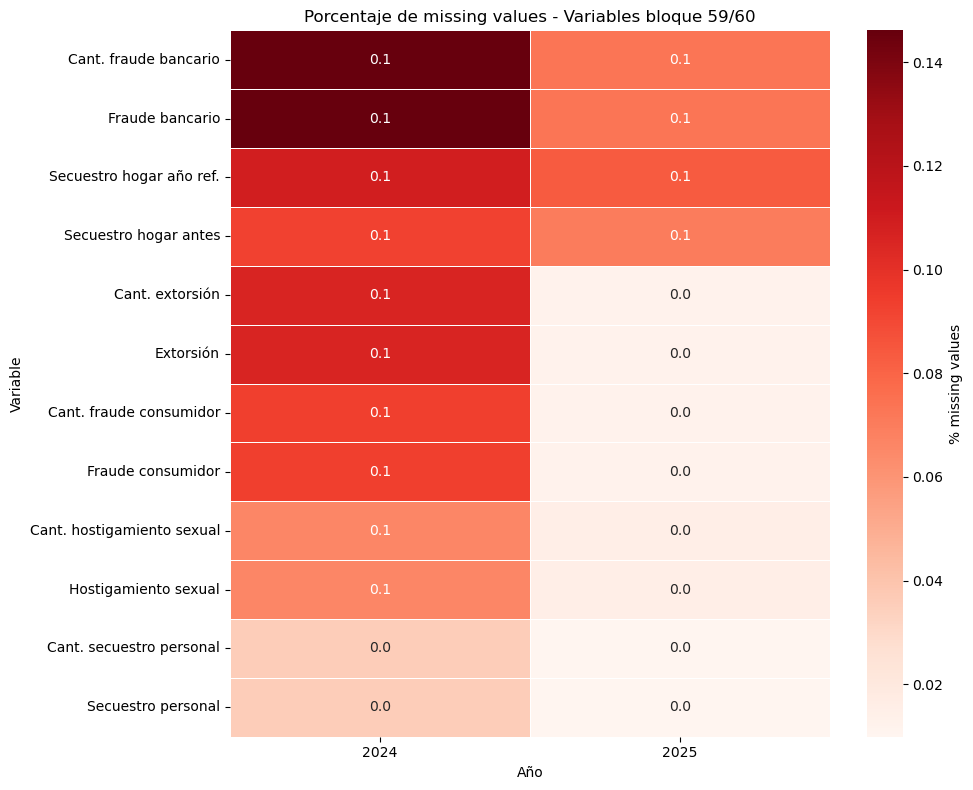

In [63]:
# ============================================================
# HEATMAP DE PORCENTAJE DE MISSING VALUES
# ============================================================

tabla_heatmap_missing = df_missing_ap.pivot_table(
    index="etiqueta",
    columns="año",
    values="porcentaje_missing"
)

# Ordenar variables por promedio de missing, de mayor a menor
tabla_heatmap_missing = tabla_heatmap_missing.loc[
    tabla_heatmap_missing.mean(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    tabla_heatmap_missing,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "% missing values"}
)

plt.title("Porcentaje de missing values - Variables bloque 59/60")
plt.xlabel("Año")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [64]:
# Relizamos un cluster

In [65]:
# ============================================================
# VARIABLES CANDIDATAS PARA CLUSTER
# ============================================================

# ------------------------------------------------------------
# Variables de cambios conductuales por temor al delito
# TPer_Vic1
# ------------------------------------------------------------

vars_conducta_cluster = [
    "AP4_10_01",
    "AP4_10_02",
    "AP4_10_03",
    "AP4_10_04",
    "AP4_10_05",
    "AP4_10_06",
    "AP4_10_08",
    "AP4_10_09",
    "AP4_10_10",
    "AP4_10_11",
    "AP4_10_12",
    "AP4_10_13",
    "AP4_10_14",
    "AP4_10_15"
]

# ------------------------------------------------------------
# Variables AP de victimización
# TPer_Vic2
# ------------------------------------------------------------

vars_victimizacion_binarias_cluster = [
    "AP6_9",      # Secuestro hogar antes
    "AP6_10_1",   # Secuestro hogar año referencia
    
    "AP7_3_07",   # Fraude bancario
    "AP7_3_08",   # Fraude consumidor
    "AP7_3_09",   # Extorsión
    "AP7_3_12",   # Secuestro personal
    "AP7_3_13"    # Hostigamiento sexual
]

vars_victimizacion_cantidad_cluster = [
    "AP7_4_07",   # Cantidad fraude bancario
    "AP7_4_08",   # Cantidad fraude consumidor
    "AP7_4_09",   # Cantidad extorsión
    "AP7_4_12",   # Cantidad secuestro personal
    "AP7_4_13"    # Cantidad hostigamiento sexual
]

# Todas las variables sueltas para cluster
vars_cluster_sueltas = (
    vars_conducta_cluster +
    vars_victimizacion_binarias_cluster +
    vars_victimizacion_cantidad_cluster
)

vars_cluster_sueltas = list(dict.fromkeys(vars_cluster_sueltas))

print("Cantidad de variables candidatas:", len(vars_cluster_sueltas))
vars_cluster_sueltas

Cantidad de variables candidatas: 26


['AP4_10_01',
 'AP4_10_02',
 'AP4_10_03',
 'AP4_10_04',
 'AP4_10_05',
 'AP4_10_06',
 'AP4_10_08',
 'AP4_10_09',
 'AP4_10_10',
 'AP4_10_11',
 'AP4_10_12',
 'AP4_10_13',
 'AP4_10_14',
 'AP4_10_15',
 'AP6_9',
 'AP6_10_1',
 'AP7_3_07',
 'AP7_3_08',
 'AP7_3_09',
 'AP7_3_12',
 'AP7_3_13',
 'AP7_4_07',
 'AP7_4_08',
 'AP7_4_09',
 'AP7_4_12',
 'AP7_4_13']

In [66]:
# ============================================================
# BLOQUE 67
# ARMAR BASE DE CLUSTER A NIVEL PERSONA
# ============================================================

bases_cluster = []

# ------------------------------------------------------------
# Caso 1: existe diccionario resultados
# ------------------------------------------------------------

if "resultados" in globals():
    
    for anio, res in resultados.items():
        
        per1 = res["per1"].copy()
        per2 = res["per2"].copy()
        
        if "ID_PER" in per1.columns and "ID_PER" in per2.columns:
            id_cols = ["ID_PER"]
        else:
            id_cols = [
                c for c in ["UPM", "VIV_SEL", "HOGAR", "R_SEL"]
                if c in per1.columns and c in per2.columns
            ]
        
        cols_per1 = id_cols + [c for c in vars_conducta_cluster if c in per1.columns]
        cols_per2 = id_cols + [
            c for c in (
                vars_victimizacion_binarias_cluster +
                vars_victimizacion_cantidad_cluster
            )
            if c in per2.columns
        ]
        
        tmp = pd.merge(
            per1[cols_per1],
            per2[cols_per2],
            on=id_cols,
            how="inner"
        )
        
        tmp["anio"] = anio
        bases_cluster.append(tmp)

# ------------------------------------------------------------
# Caso 2: no existe resultados, intenta usar nombres de bases
# ------------------------------------------------------------

else:
    
    posibles_bases = {}
    
    if "df_TPer_Vic1_2024" in globals() and "df_TPer_Vic2_2024" in globals():
        posibles_bases[2024] = {
            "per1": df_TPer_Vic1_2024,
            "per2": df_TPer_Vic2_2024
        }
    
    if "df_TPer_Vic1" in globals() and "df_TPer_Vic2" in globals():
        posibles_bases[2025] = {
            "per1": df_TPer_Vic1,
            "per2": df_TPer_Vic2
        }
    
    for anio, res in posibles_bases.items():
        
        per1 = res["per1"].copy()
        per2 = res["per2"].copy()
        
        if "ID_PER" in per1.columns and "ID_PER" in per2.columns:
            id_cols = ["ID_PER"]
        else:
            id_cols = [
                c for c in ["UPM", "VIV_SEL", "HOGAR", "R_SEL"]
                if c in per1.columns and c in per2.columns
            ]
        
        cols_per1 = id_cols + [c for c in vars_conducta_cluster if c in per1.columns]
        cols_per2 = id_cols + [
            c for c in (
                vars_victimizacion_binarias_cluster +
                vars_victimizacion_cantidad_cluster
            )
            if c in per2.columns
        ]
        
        tmp = pd.merge(
            per1[cols_per1],
            per2[cols_per2],
            on=id_cols,
            how="inner"
        )
        
        tmp["anio"] = anio
        bases_cluster.append(tmp)

df_cluster_base = pd.concat(bases_cluster, ignore_index=True)

print("Dimensión de la base para cluster:", df_cluster_base.shape)
df_cluster_base.head()

Dimensión de la base para cluster: (180812, 28)


,ID_PER,AP4_10_01,AP4_10_02,AP4_10_03,AP4_10_04,AP4_10_05,AP4_10_06,AP4_10_08,AP4_10_09,AP4_10_10,...,AP7_3_08,AP7_3_09,AP7_3_12,AP7_3_13,AP7_4_07,AP7_4_08,AP7_4_09,AP7_4_12,AP7_4_13,anio
0,0100005.01.01.03,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
1,0100005.03.01.02,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
2,0100005.04.01.01,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
3,0100005.05.01.01,1.0,1.0,1.0,NaN,NaN,0.0,0.0,1.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
4,0100012.02.01.02,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024


In [67]:
# ============================================================
# BLOQUE 68
# DIAGNÓSTICO DE VARIABLES SUELTAS
# ============================================================

vars_cluster_presentes = [
    v for v in vars_cluster_sueltas
    if v in df_cluster_base.columns
]

# Convertir a numérico
for v in vars_cluster_presentes:
    df_cluster_base[v] = pd.to_numeric(df_cluster_base[v], errors="coerce")

diagnostico_cluster_sueltas = []

for v in vars_cluster_presentes:
    
    s = df_cluster_base[v]
    
    diagnostico_cluster_sueltas.append({
        "variable": v,
        "n_total": len(s),
        "n_missing": s.isna().sum(),
        "pct_missing": s.isna().mean() * 100,
        "n_unique_no_missing": s.dropna().nunique(),
        "media": s.mean(skipna=True),
        "min": s.min(skipna=True),
        "max": s.max(skipna=True)
    })

diagnostico_cluster_sueltas = pd.DataFrame(diagnostico_cluster_sueltas)

diagnostico_cluster_sueltas = diagnostico_cluster_sueltas.sort_values(
    "pct_missing",
    ascending=False
).reset_index(drop=True)

diagnostico_cluster_sueltas

,variable,n_total,n_missing,pct_missing,n_unique_no_missing,media,min,max
0,AP4_10_13,180812,116770,64.580891,2,0.200431,0.0,1.0
1,AP4_10_08,180812,81917,45.305068,2,0.231003,0.0,1.0
2,AP4_10_02,180812,68331,37.791186,2,0.616975,0.0,1.0
3,AP4_10_10,180812,65044,35.973276,2,0.425809,0.0,1.0
4,AP4_10_04,180812,47516,26.279229,2,0.307939,0.0,1.0
5,AP4_10_05,180812,44519,24.621707,2,0.218023,0.0,1.0
6,AP4_10_12,180812,43670,24.152158,2,0.237921,0.0,1.0
7,AP4_10_14,180812,31420,17.377165,2,0.162305,0.0,1.0
8,AP4_10_09,180812,21272,11.764706,2,0.305159,0.0,1.0
9,AP4_10_11,180812,20099,11.115966,2,0.223324,0.0,1.0


In [68]:
# ============================================================
# SELECCIÓN DE VARIABLES PARA CLUSTER
# ============================================================

vars_cluster_final = diagnostico_cluster_sueltas.loc[
    (diagnostico_cluster_sueltas["n_unique_no_missing"] > 1) &
    (diagnostico_cluster_sueltas["pct_missing"] < 100),
    "variable"
].tolist()

print("Variables usadas finalmente en el cluster:", len(vars_cluster_final))
vars_cluster_final

Variables usadas finalmente en el cluster: 26


['AP4_10_13',
 'AP4_10_08',
 'AP4_10_02',
 'AP4_10_10',
 'AP4_10_04',
 'AP4_10_05',
 'AP4_10_12',
 'AP4_10_14',
 'AP4_10_09',
 'AP4_10_11',
 'AP4_10_15',
 'AP4_10_01',
 'AP4_10_03',
 'AP4_10_06',
 'AP7_3_07',
 'AP7_4_07',
 'AP6_10_1',
 'AP6_9',
 'AP7_3_09',
 'AP7_4_09',
 'AP7_3_08',
 'AP7_4_08',
 'AP7_3_13',
 'AP7_4_13',
 'AP7_3_12',
 'AP7_4_12']

In [69]:
# Prevalencia: proporción de personas con valor > 0 en cada variable
prevalencia = (df_cluster_base[vars_cluster_final] > 0).mean().sort_values()
print(prevalencia.round(4))

AP7_4_12     0.0008
AP7_3_12     0.0008
AP6_10_1     0.0020
AP7_4_13     0.0117
AP7_3_13     0.0117
AP6_9        0.0144
AP7_4_08     0.0277
AP7_3_08     0.0277
AP7_4_07     0.0315
AP7_3_07     0.0315
AP7_4_09     0.0435
AP7_3_09     0.0435
AP4_10_13    0.0710
AP4_10_08    0.1263
AP4_10_14    0.1341
AP4_10_05    0.1643
AP4_10_12    0.1805
AP4_10_11    0.1985
AP4_10_15    0.2175
AP4_10_04    0.2270
AP4_10_09    0.2693
AP4_10_10    0.2726
AP4_10_03    0.2857
AP4_10_02    0.3838
AP4_10_06    0.3999
AP4_10_01    0.4105
dtype: float64


In [70]:
UMBRAL_PREVALENCIA = 0.01   # 1% — ajustalo si querés

vars_raras = prevalencia[prevalencia < UMBRAL_PREVALENCIA].index.tolist()
print("Descartadas por ser demasiado raras:", vars_raras)

vars_cluster_final = [v for v in vars_cluster_final if v not in vars_raras]
print("Variables que quedan para el cluster:", len(vars_cluster_final))

Descartadas por ser demasiado raras: ['AP7_4_12', 'AP7_3_12', 'AP6_10_1']
Variables que quedan para el cluster: 23


In [71]:
# ============================================================
# MATRIZ X PARA CLUSTER 
# ============================================================
X_cluster = df_cluster_base[vars_cluster_final].copy()

for v in vars_cluster_final:
    X_cluster[v] = pd.to_numeric(X_cluster[v], errors="coerce")

# Agrupamos las variables según su naturaleza (solo las que entraron al cluster)
cant_cols     = [v for v in vars_victimizacion_cantidad_cluster if v in vars_cluster_final]
bin_vict_cols = [v for v in vars_victimizacion_binarias_cluster if v in vars_cluster_final]
conducta_cols = [v for v in vars_conducta_cluster              if v in vars_cluster_final]

# Cantidades: el faltante = "no fue víctima" -> se imputa 0 (NO la mediana).
# Luego log1p para suavizar valores extremos y StandardScaler.
pipe_cantidades = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("log",     FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler",  StandardScaler())
])

# Binarias (victimización + conducta): faltante = "no" -> 0
pipe_binarias = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler",  StandardScaler())
])

preprocess_cluster = ColumnTransformer(transformers=[
    ("cant", pipe_cantidades, cant_cols),
    ("bin",  pipe_binarias,   bin_vict_cols + conducta_cols),
])

X_cluster_scaled = preprocess_cluster.fit_transform(X_cluster)

print("Dimensión de X:", X_cluster_scaled.shape)
print("Cantidades imputadas con 0 (no víctima):", cant_cols)

Dimensión de X: (180812, 23)
Cantidades imputadas con 0 (no víctima): ['AP7_4_07', 'AP7_4_08', 'AP7_4_09', 'AP7_4_13']


In [72]:
# ============================================================
# EVALUACIÓN DE K: ELBOW + SILHOUETTE
# ============================================================

resultados_k = []

K_POSIBLES = range(2, 11)

N_MUESTRA_SILHOUETTE = min(5000, X_cluster_scaled.shape[0])

np.random.seed(123)

idx_muestra = np.random.choice(
    X_cluster_scaled.shape[0],
    size=N_MUESTRA_SILHOUETTE,
    replace=False
)

X_silhouette = X_cluster_scaled[idx_muestra]

for k in K_POSIBLES:
    
    print(f"Evaluando k = {k}...")
    
    km = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=10,
    max_iter=300
)
    labels = km.fit_predict(X_cluster_scaled)
    
    sil = silhouette_score(
        X_silhouette,
        labels[idx_muestra]
    )
    
    resultados_k.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette_muestra": sil
    })

df_resultados_k = pd.DataFrame(resultados_k)

df_resultados_k

Evaluando k = 2...
Evaluando k = 3...
Evaluando k = 4...
Evaluando k = 5...
Evaluando k = 6...
Evaluando k = 7...
Evaluando k = 8...
Evaluando k = 9...
Evaluando k = 10...


,k,inertia,silhouette_muestra
0,2,3.342376e+06,0.392647
1,3,3.010305e+06,0.399079
2,4,2.701332e+06,0.406548
3,5,2.515859e+06,0.344232
4,6,2.187819e+06,0.428209
5,7,2.016180e+06,0.366626
6,8,1.940163e+06,0.301656
7,9,1.802566e+06,0.362150
8,10,1.717081e+06,0.311903


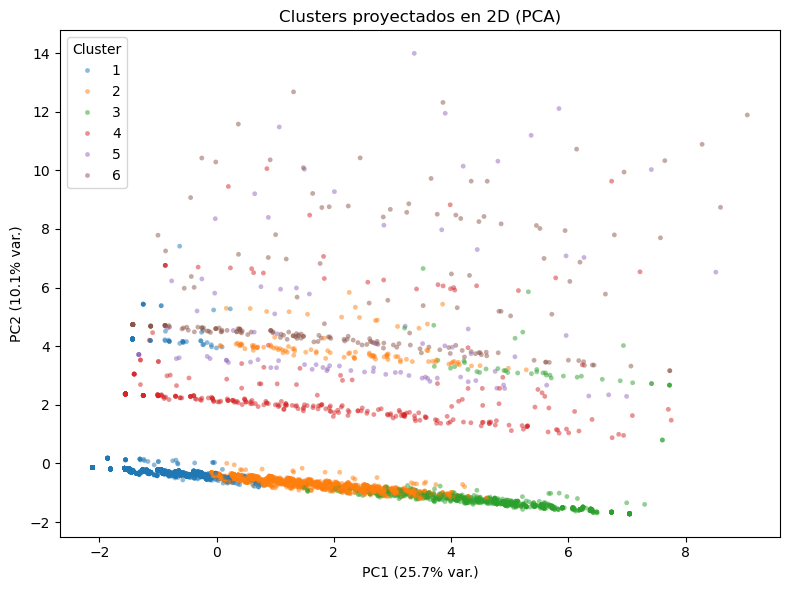

In [73]:
# ============================================================
# BLOQUE 72
# CLUSTER FINAL DIRECTO SOBRE VARIABLES SUELTAS
# ============================================================

K_ELEGIDO = 6

cluster_model = MiniBatchKMeans(
    n_clusters=K_ELEGIDO,
    random_state=123,
    n_init=50,
    batch_size=2048,
    max_iter=300
)

df_cluster_resultado = df_cluster_base.copy()

df_cluster_resultado["cluster"] = cluster_model.fit_predict(X_cluster_scaled) + 1

df_cluster_resultado[["anio", "cluster"] + vars_cluster_final].head()

# ============================================================
# NUBE DE PUNTOS: PROYECCIÓN PCA 2D COLOREADA POR CLUSTER
# (PCA solo para visualizar; no cambia el clustering)
# ============================================================
pca = PCA(n_components=2, random_state=123)
coords = pca.fit_transform(X_cluster_scaled)

df_plot = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "cluster": df_cluster_resultado["cluster"].values
})

# Con ~180k puntos conviene graficar una muestra para que se vea
df_plot_m = df_plot.sample(n=min(8000, len(df_plot)), random_state=123)

var_exp = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot_m, x="PC1", y="PC2",
    hue="cluster", palette="tab10",
    s=12, alpha=0.5, linewidth=0
)
plt.title("Clusters proyectados en 2D (PCA)")
plt.xlabel(f"PC1 ({var_exp[0]:.1f}% var.)")
plt.ylabel(f"PC2 ({var_exp[1]:.1f}% var.)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# BLOQUE 73
# TAMAÑO DE CLUSTERS
# ============================================================

tam_clusters = (
    df_cluster_resultado
    .groupby("cluster")
    .size()
    .reset_index(name="n")
)

tam_clusters["porcentaje"] = tam_clusters["n"] / tam_clusters["n"].sum() * 100

tam_clusters

,cluster,n,porcentaje
0,1,109105,60.341681
1,2,40359,22.320974
2,3,17483,9.669159
3,4,7019,3.881933
4,5,2118,1.171382
5,6,4728,2.614871


In [75]:
# ============================================================
# BLOQUE 74
# PERFIL PROMEDIO DE CLUSTERS
# Variables sueltas, sin índices
# ============================================================

perfil_clusters = (
    df_cluster_resultado
    .groupby("cluster")[vars_cluster_final]
    .mean()
    .reset_index()
)

perfil_clusters

,cluster,AP4_10_13,AP4_10_08,AP4_10_02,AP4_10_10,AP4_10_04,AP4_10_05,AP4_10_12,AP4_10_14,AP4_10_09,...,AP4_10_06,AP7_3_07,AP7_4_07,AP6_9,AP7_3_09,AP7_4_09,AP7_3_08,AP7_4_08,AP7_3_13,AP7_4_13
0,1,0.018607,0.019266,0.435180,0.128044,0.053384,0.031066,0.050862,0.017554,0.047244,...,0.166413,0.013918,0.016230,0.008926,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,0.113223,0.266200,0.871749,0.724286,0.604184,0.420639,0.380132,0.176517,0.617442,...,0.773461,0.046000,0.055944,0.018073,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,0.908550,0.874797,0.885111,0.930717,0.828046,0.671283,0.794562,0.807453,0.904601,...,0.894160,0.045244,0.057500,0.026680,0.003950,0.003950,0.000000,0.000000,0.000000,0.000000
3,4,0.283632,0.318192,0.722469,0.573901,0.416522,0.311167,0.306355,0.213051,0.431116,...,0.568523,0.071949,0.097787,0.029802,1.000000,1.282234,0.002711,0.002854,0.000000,0.000000
4,5,0.345898,0.304324,0.783033,0.613139,0.587335,0.395745,0.327675,0.248376,0.579181,...,0.622561,0.125533,0.162956,0.036827,0.109375,0.145833,0.125768,0.158865,1.000000,1.575071
5,6,0.315452,0.280011,0.743339,0.598802,0.472668,0.362158,0.287210,0.220247,0.443445,...,0.615188,0.160237,0.215769,0.029617,0.115140,0.151399,1.000000,1.168147,0.000423,0.000423


In [76]:
# ============================================================
# BLOQUE 75
# ETIQUETAS DE VARIABLES
# ============================================================

etiquetas_cluster = {
    "AP4_10_01": "Dejó de salir de noche",
    "AP4_10_02": "Dejó de permitir menores salgan",
    "AP4_10_03": "Dejó de visitar parientes/amigos",
    "AP4_10_04": "Dejó de tomar taxi",
    "AP4_10_05": "Dejó de usar transporte público",
    "AP4_10_06": "Dejó de llevar dinero",
    "AP4_10_08": "Dejó de ir a la escuela",
    "AP4_10_09": "Dejó de ir al cine/teatro",
    "AP4_10_10": "Dejó de salir a caminar",
    "AP4_10_11": "Dejó de usar joyas",
    "AP4_10_12": "Dejó de salir a comer",
    "AP4_10_13": "Dejó de ir al banco/cajero",
    "AP4_10_14": "Dejó de llevar tarjeta",
    "AP4_10_15": "Dejó de usar teléfono en público",
    
    "AP6_9": "Secuestro hogar antes",
    "AP6_10_1": "Secuestro hogar año ref.",
    
    "AP7_3_07": "Fraude bancario",
    "AP7_3_08": "Fraude consumidor",
    "AP7_3_09": "Extorsión",
    "AP7_3_12": "Secuestro personal",
    "AP7_3_13": "Hostigamiento sexual",
    
    "AP7_4_07": "Cantidad fraude bancario",
    "AP7_4_08": "Cantidad fraude consumidor",
    "AP7_4_09": "Cantidad extorsión",
    "AP7_4_12": "Cantidad secuestro personal",
    "AP7_4_13": "Cantidad hostigamiento sexual"
}

In [77]:
# ============================================================
# BLOQUE 76
# VARIABLES MÁS ALTAS POR CLUSTER
# ============================================================

perfil_largo = perfil_clusters.melt(
    id_vars="cluster",
    var_name="variable",
    value_name="media_cluster"
)

perfil_largo["etiqueta"] = perfil_largo["variable"].map(
    etiquetas_cluster
).fillna(perfil_largo["variable"])

# Media global de cada variable
media_global = (
    df_cluster_resultado[vars_cluster_final]
    .mean()
    .reset_index()
)

media_global.columns = ["variable", "media_global"]

perfil_largo = perfil_largo.merge(
    media_global,
    on="variable",
    how="left"
)

perfil_largo["diferencia_vs_global"] = (
    perfil_largo["media_cluster"] - perfil_largo["media_global"]
)

top_variables_por_cluster = (
    perfil_largo
    .sort_values(["cluster", "diferencia_vs_global"], ascending=[True, False])
    .groupby("cluster")
    .head(8)
    .reset_index(drop=True)
)

top_variables_por_cluster[
    [
        "cluster",
        "etiqueta",
        "media_cluster",
        "media_global",
        "diferencia_vs_global"
    ]
]

,cluster,etiqueta,media_cluster,media_global,diferencia_vs_global
0,1,Secuestro hogar antes,0.008926,0.014364,-0.005437
1,1,Hostigamiento sexual,0.000000,0.011730,-0.011730
2,1,Fraude bancario,0.013918,0.031487,-0.017569
3,1,Cantidad hostigamiento sexual,0.000000,0.018469,-0.018469
4,1,Cantidad fraude bancario,0.016230,0.039177,-0.022947
5,1,Fraude consumidor,0.000000,0.027740,-0.027740
6,1,Cantidad fraude consumidor,0.000000,0.032532,-0.032532
7,1,Extorsión,0.000000,0.043507,-0.043507
8,2,Dejó de salir de noche,0.844545,0.445183,0.399362
9,2,Dejó de llevar dinero,0.773461,0.408287,0.365175


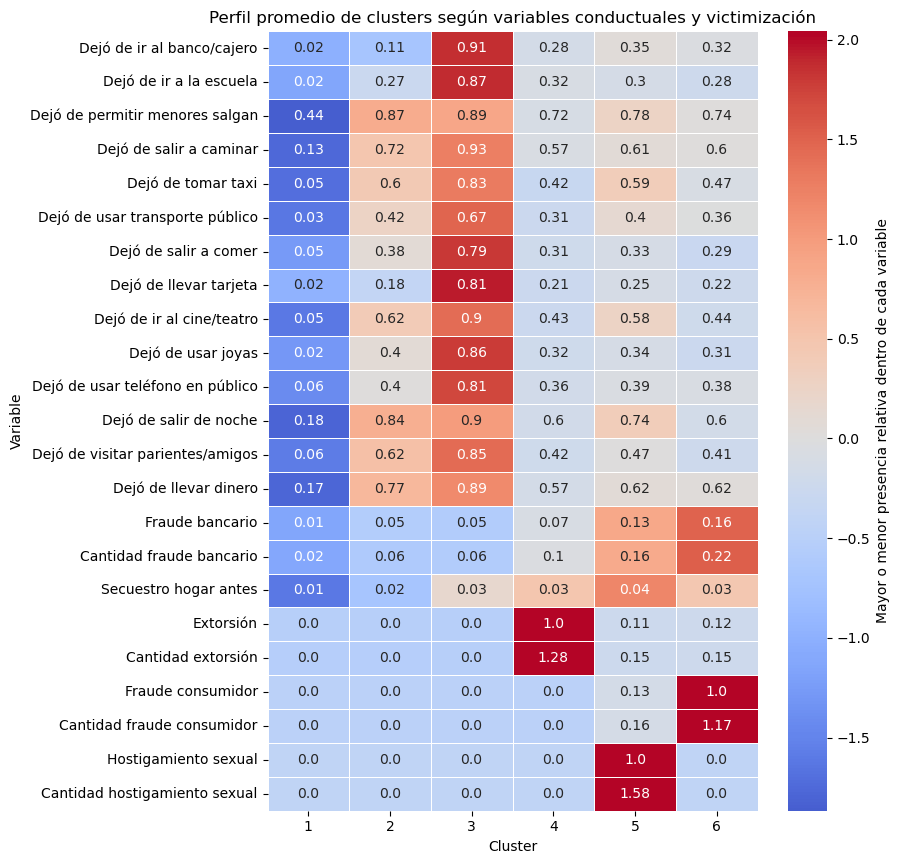

In [78]:
# ============================================================
# BLOQUE 77
# HEATMAP DEL PERFIL DE CLUSTERS
# Variables sueltas
# ============================================================

tabla_medias = perfil_clusters.set_index("cluster").T

# Renombrar filas
tabla_medias.index = [
    etiquetas_cluster.get(v, v)
    for v in tabla_medias.index
]

# Para colorear, estandarizamos por variable.
# Las anotaciones siguen mostrando las medias reales.
tabla_colores = tabla_medias.copy()

tabla_colores = tabla_colores.sub(
    tabla_colores.mean(axis=1),
    axis=0
).div(
    tabla_colores.std(axis=1).replace(0, np.nan),
    axis=0
)

plt.figure(figsize=(9, max(7, len(tabla_medias) * 0.38)))

sns.heatmap(
    tabla_colores,
    annot=tabla_medias.round(2),
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mayor o menor presencia relativa dentro de cada variable"}
)

plt.title("Perfil promedio de clusters según variables conductuales y victimización")
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# BLOQUE 78
# GUARDAR RESULTADOS
# ============================================================

df_cluster_resultado.to_csv(
    "cluster_directo_variables_sueltas.csv",
    index=False
)

perfil_clusters.to_csv(
    "perfil_cluster_variables_sueltas.csv",
    index=False
)

top_variables_por_cluster.to_csv(
    "top_variables_por_cluster.csv",
    index=False
)

print("Resultados guardados correctamente.")

Resultados guardados correctamente.


In [80]:
# ============================================================
# CHEQUEO RÁPIDO: TAMAÑOS POR CLUSTER (diagnóstico)
# ============================================================
for k in [3, 6]:
    m = KMeans(n_clusters=k, random_state=123, n_init=10).fit(X_cluster_scaled)
    tam = pd.Series(m.labels_).value_counts(normalize=True).mul(100).round(1)
    print(f"\nk={k}:")
    print(tam.sort_index())


k=3:
0     2.8
1    26.6
2    70.6
Name: proportion, dtype: float64

k=6:
0    66.8
1    23.2
2     2.9
3     3.7
4     2.2
5     1.2
Name: proportion, dtype: float64


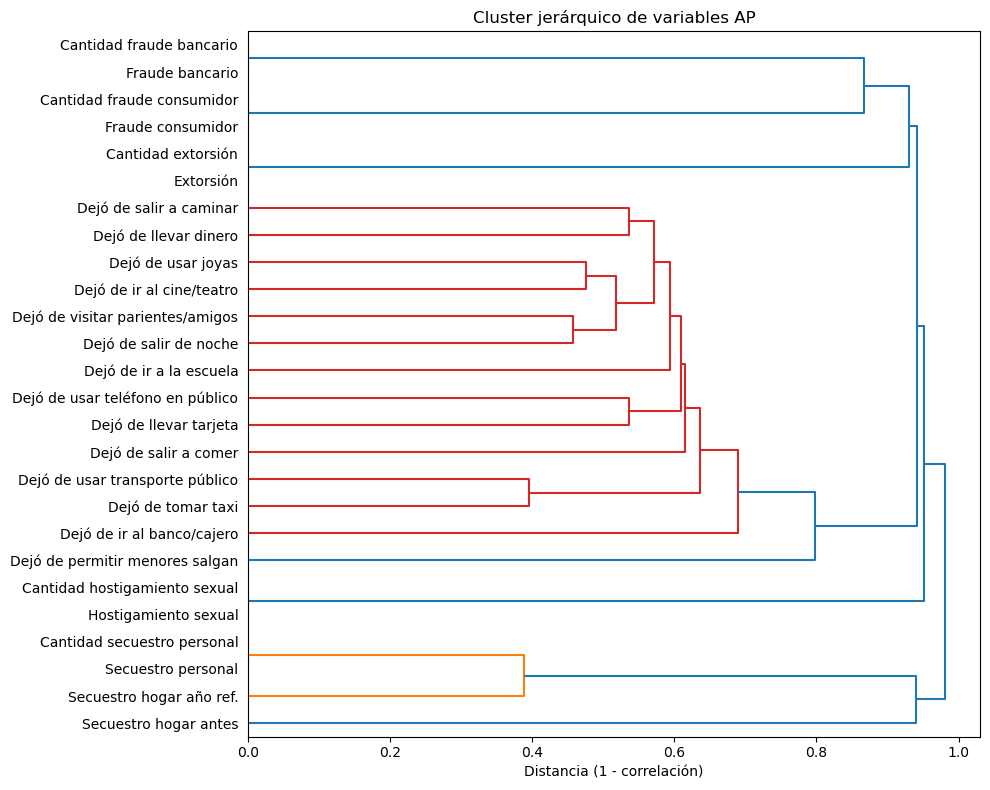

In [81]:
# ============================================================
# CLUSTER JERÁRQUICO DE VARIABLES — SECCIÓN AP
# (agrupa las VARIABLES según cuánto se mueven juntas)
# ============================================================

# 1. Las mismas variables AP que veníamos trabajando
vars_ap_hc = (
    vars_conducta_cluster +
    vars_victimizacion_binarias_cluster +
    vars_victimizacion_cantidad_cluster
)
vars_ap_hc = [v for v in vars_ap_hc if v in df_cluster_base.columns]

# 2. Imputamos no-víctimas como 0 ANTES de correlacionar.
#    Esto es lo que evita el problema de "no results" que tenías:
#    si dejás los NaN, la correlación se calcula sobre muestras
#    distintas para cada par y se rompe.
X_ap = df_cluster_base[vars_ap_hc].apply(pd.to_numeric, errors="coerce").fillna(0)

# Descartamos columnas constantes (no se les puede calcular correlación)
X_ap = X_ap.loc[:, X_ap.std() > 0]

# 3. Correlación de Spearman: robusta para mezcla de binarias y conteos
corr = X_ap.corr(method="spearman")

# 4. Etiquetas legibles
corr_lab = corr.rename(index=etiquetas_cluster, columns=etiquetas_cluster)

# 5. Distancia = 1 - correlación  →  linkage jerárquico (average)
dist = (1 - corr).values
np.fill_diagonal(dist, 0)          # asegura diagonal exacta en 0
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="average")

# 6. Solo el árbol (dendrograma)
plt.figure(figsize=(10, 8))

dendrogram(
    Z,
    labels=[etiquetas_cluster.get(v, v) for v in corr.columns],
    orientation="right",        # etiquetas horizontales, legibles
    color_threshold=0.7,        # colorea las ramas por grupo
    leaf_font_size=10
)

plt.title("Cluster jerárquico de variables AP")
plt.xlabel("Distancia (1 - correlación)")
plt.tight_layout()
plt.show()

In [89]:
# Cortamos el dendrograma en k grupos de variables (probá 3, 4, 5...)
K_GRUPOS_VAR = 3

grupos_var = fcluster(Z, t=K_GRUPOS_VAR, criterion="maxclust")

tabla_grupos = pd.DataFrame({
    "variable": corr.columns,
    "etiqueta": [etiquetas_cluster.get(v, v) for v in corr.columns],
    "grupo": grupos_var
}).sort_values(["grupo", "etiqueta"]).reset_index(drop=True)

tabla_grupos

,variable,etiqueta,grupo
0,AP7_4_12,Cantidad secuestro personal,1
1,AP6_9,Secuestro hogar antes,1
2,AP6_10_1,Secuestro hogar año ref.,1
3,AP7_3_12,Secuestro personal,1
4,AP7_4_13,Cantidad hostigamiento sexual,2
5,AP7_3_13,Hostigamiento sexual,2
6,AP7_4_09,Cantidad extorsión,3
7,AP7_4_07,Cantidad fraude bancario,3
8,AP7_4_08,Cantidad fraude consumidor,3
9,AP4_10_08,Dejó de ir a la escuela,3


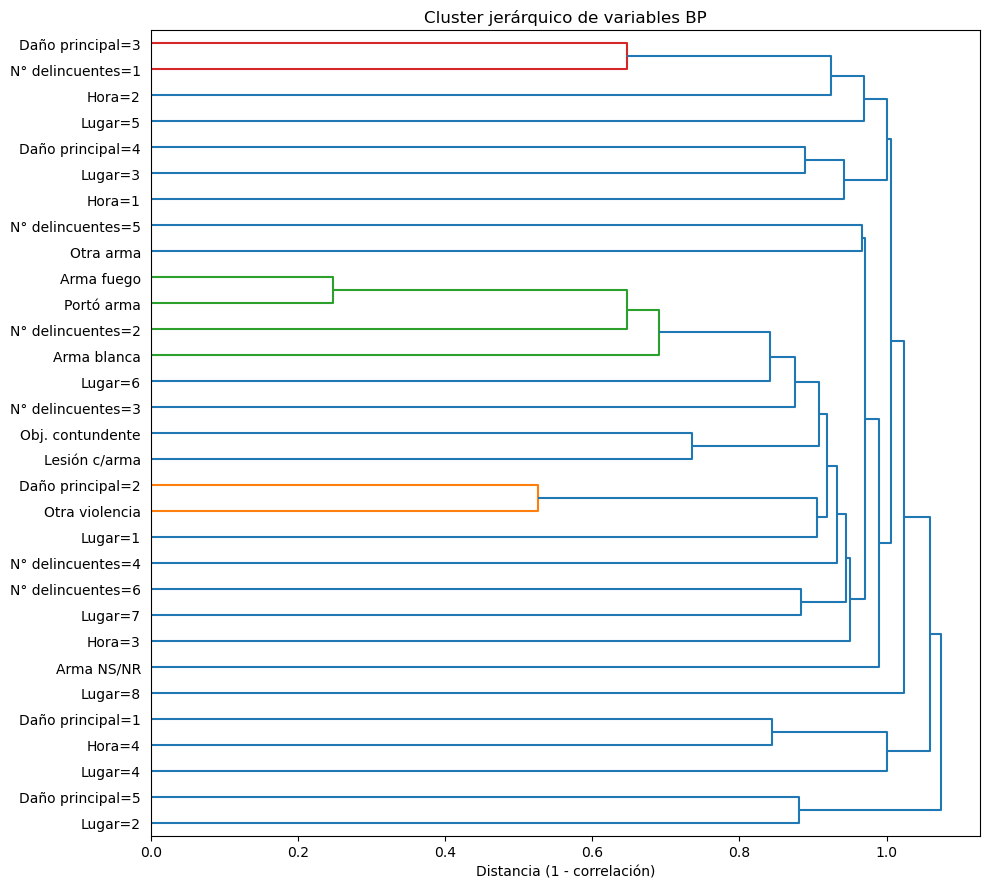

In [87]:
# ============================================================
# CLUSTER JERÁRQUICO DE VARIABLES — SECCIÓN BP
# OJO: BP está a nivel DELITO (df_Mod_Vic), no a nivel persona
# ============================================================

# 1. Juntamos ambos años a nivel delito
df_bp = pd.concat(
    [normalizar_columnas(df_Mod_Vic), normalizar_columnas(df_Mod_Vic_2024)],
    ignore_index=True
)

# 2. Binarias -> 0/1
bp_bin_presentes = [c for c in bp_binarias if c in df_bp.columns]
X_bin = pd.DataFrame({c: a_binaria_01(df_bp[c]) for c in bp_bin_presentes})

# 3. Categóricas -> dummies (una columna 0/1 por categoría)
dummies = []
for col in bp_categoricas:
    if col not in df_bp.columns:
        continue
    x = normalizar_valores(df_bp[col])
    x = x.mask(x.isin(["", "B", "BLANCO", "NAN", "<NA>", "9", "99", "999"]))
    dummies.append(pd.get_dummies(x, prefix=col, dummy_na=False).astype(int))

X_cat = pd.concat(dummies, axis=1) if dummies else pd.DataFrame(index=df_bp.index)

# 4. Unimos todo. Como queda todo 0/1, imputamos faltantes como 0
X_bp = pd.concat([X_bin, X_cat], axis=1).fillna(0)
X_bp = X_bp.loc[:, X_bp.std() > 0]          # fuera columnas constantes

# 5. Etiquetas legibles
X_bp = X_bp.rename(columns={c: etiqueta_columna_bp(c) for c in X_bp.columns})

# 6. Correlación de Spearman -> distancia -> linkage
corr_bp = X_bp.corr(method="spearman")
dist_bp = (1 - corr_bp).values
np.fill_diagonal(dist_bp, 0)
Z_bp = linkage(squareform(dist_bp, checks=False), method="average")

# 7. Dendrograma
plt.figure(figsize=(10, 9))
dendrogram(
    Z_bp,
    labels=corr_bp.columns.tolist(),
    orientation="right",
    color_threshold=0.7,
    leaf_font_size=10
)
plt.title("Cluster jerárquico de variables BP")
plt.xlabel("Distancia (1 - correlación)")
plt.tight_layout()
plt.show()

In [88]:
K_GRUPOS_BP = 4   # ajustalo según lo que muestre el árbol

grupos_bp = fcluster(Z_bp, t=K_GRUPOS_BP, criterion="maxclust")

tabla_grupos_bp = pd.DataFrame({
    "variable": corr_bp.columns,
    "grupo": grupos_bp
}).sort_values(["grupo", "variable"]).reset_index(drop=True)

tabla_grupos_bp

,variable,grupo
0,Daño principal=5,1
1,Lugar=2,1
2,Daño principal=1,2
3,Hora=4,2
4,Lugar=4,2
5,Arma NS/NR,3
6,Arma blanca,3
7,Arma fuego,3
8,Daño principal=2,3
9,Daño principal=3,3


In [90]:
import os

carpeta = r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\datos_limpios"
os.makedirs(carpeta, exist_ok=True)

tablas = {
    "TMod_Vic_2025":  df_Mod_Vic,
    "TMod_Vic_2024":  df_Mod_Vic_2024,
    "TPer_Vic1_2025": df_TPer_Vic1,
    "TPer_Vic2_2025": df_TPer_Vic2,
    "TPer_Vic1_2024": df_TPer_Vic1_2024,
    "TPer_Vic2_2024": df_TPer_Vic2_2024,
    "TSDem_2025":     df_TSDem,
    "TSDem_2024":     df_TSDem_2024,
}

for nombre, df in tablas.items():
    df.to_csv(os.path.join(carpeta, f"{nombre}_limpio.csv"), index=False)

print("Tablas limpias guardadas en:", carpeta)

Tablas limpias guardadas en: C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\Poster correciones\datos_limpios
